<a href="https://colab.research.google.com/github/pranavkagrawal02/AI-Driven-Retail-Inventory-and-Replenishment/blob/main/AI_Retail_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load Libraries

In [43]:
pip install tensorflow.keras

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from tensorflow.keras import layers, models

# Load Datasets


In [ ]:
# Read the CSV file from the Colab environment
calendar = pd.read_csv("calendar.csv")
print(calendar)

In [ ]:
sellprices=pd.read_csv("sell_prices.csv")
print(sellprices)

In [ ]:
salestrainevaluation=pd.read_csv("sales_train_evaluation.csv")
print(salestrainevaluation)

# DataSet Trend Analysis - Graphs

In [ ]:
calendar.columns = calendar.columns.str.strip()

print(calendar.columns.tolist())  # ← verify names

# --- Event frequency bar chart (top 15) ---
event_counts = calendar['event_type_1'].value_counts().head(15)

plt.figure(figsize=(10,5))
plt.bar(event_counts.index.astype(str), event_counts.values)
plt.xticks(rotation=45, ha='right')
plt.title("Top 15 Most Frequent Events")
plt.xlabel("Event Name")
plt.ylabel("Number of Days")
plt.tight_layout()
plt.show()

event_counts = calendar['event_name_1'].value_counts().head(15)

plt.figure(figsize=(10,5))
plt.bar(event_counts.index.astype(str), event_counts.values)
plt.xticks(rotation=45, ha='right')
plt.title("Top 15 Most Frequent Events")
plt.xlabel("Event Name")
plt.ylabel("Number of Days")
plt.tight_layout()
plt.show()

event_counts = calendar['event_type_2'].value_counts().head(15)

plt.figure(figsize=(10,5))
plt.bar(event_counts.index.astype(str), event_counts.values)
plt.xticks(rotation=45, ha='right')
plt.title("Top 15 Most Frequent Events")
plt.xlabel("Event Name")
plt.ylabel("Number of Days")
plt.tight_layout()
plt.show()

event_counts = calendar['event_name_2'].value_counts().head(15)

plt.figure(figsize=(10,5))
plt.bar(event_counts.index.astype(str), event_counts.values)
plt.xticks(rotation=45, ha='right')
plt.title("Top 15 Most Frequent Events")
plt.xlabel("Event Name")
plt.ylabel("Number of Days")
plt.tight_layout()
plt.show()

In [ ]:
# Events by month (seasonality)
calendar['date'] = pd.to_datetime(calendar['date'])
monthly_events = calendar.groupby(calendar['date'].dt.month)['event_name_1'].count()
plt.figure(figsize=(7,4))
plt.plot(monthly_events.index, monthly_events.values, marker='o')
plt.title("Events per Month")
plt.xlabel("Month (1–12)")
plt.ylabel("Count")
plt.grid(True)
plt.show()

# SNAP weekday heatmap-style table (simple matplotlib)
wk = calendar['date'].dt.day_name()
snap = calendar.groupby(wk)[['snap_CA','snap_TX','snap_WI']].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)
print(snap.round(3))  # or plot with imshow if you want a heatmap

# Model 1 - Simple Average-Based Approach

** Task**
Generate predictions for the next 28 days based on the provided `calendar.csv`, `sell_prices.csv`, and `sales_train_evaluation.csv` datasets. The predictions should be in the format of `sample_submission.csv`. Use a memory-efficient model that processes data in chunks and avoids complex feature engineering. The final output should be a CSV file containing the predictions.

**Task**
Generate predictions for the next 28 days based on the provided `calendar.csv`, `sell_prices.csv`, and `sales_train_evaluation.csv` datasets. The predictions should be in the format of `sample_submission.csv`. Use a memory-efficient model that processes data in chunks and avoids complex feature engineering. The final output should be a CSV file containing the predictions.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

**Inspect `sample submission.csv**

***Subtask:***

Load and inspect the `sample_submission.csv` file to understand the exact format required for the predictions.


**Reasoning**:
Load the `sample_submission.csv` file and display its head and column names to understand the required submission format.



In [ ]:
submission = pd.read_csv("sample_submission.csv")
display(submission.head())
print(submission.columns.tolist())

**Process `sales train evaluation.csv` in chunks**

**Subtask:**

Process `sales train evaluation.csv` in chunks


**Reasoning**:
Define the chunk size and initialize an empty list to store processed chunks.



In [ ]:
chunk_size = 1000
processed_chunks = []

**Reasoning**:
Iterate through the `sales_train_evaluation.csv` file in chunks and process each chunk.



In [ ]:
for chunk in pd.read_csv("sales_train_evaluation.csv", chunksize=chunk_size):
    # In a real scenario, processing would happen here.
    # For this subtask, we just append the chunk to the list to demonstrate chunking.
    processed_chunks.append(chunk)
    print(f"Processed chunk with {len(chunk)} rows.")

print(f"Total chunks processed: {len(processed_chunks)}")

**Implement a prediction strategy**

**Subtask: **

For each item in each chunk, implement a simple prediction strategy for the next 28 days. Given the constraints, a simple approach like predicting the average of the last few known sales days or the last known sales value could be used as a baseline.


**Reasoning**:
Implement the prediction strategy for each item in each chunk by calculating the average of the last 28 sales days and storing the predictions.



In [ ]:
predictions_list = []

for chunk in processed_chunks:
    # Select the columns containing the daily sales data
    sales_cols = [col for col in chunk.columns if 'd_' in col]

    # Iterate through each item in the chunk
    for index, row in chunk.iterrows():
        item_id = row['id']
        sales_data = row[sales_cols].values

        # Handle potential missing values (NaNs) by filling with 0
        sales_data = np.nan_to_num(sales_data, nan=0)

        # Calculate the average of the last 28 sales values
        # Ensure there are at least 28 days of sales data
        if len(sales_data) >= 28:
            average_sales = np.mean(sales_data[-28:])
        else:
            # If less than 28 days of data, calculate the average of available data
            average_sales = np.mean(sales_data) if len(sales_data) > 0 else 0

        # Create a list of predictions for the next 28 days
        # Predict the calculated average for each of the 28 future days
        predictions = [average_sales] * 28

        # Store the item's id and predictions
        predictions_list.append({'id': item_id, 'predictions': predictions})

print(f"Generated predictions for {len(predictions_list)} items.")

**Format predictions**

**Subtask:**

Format the predictions for each item to match the `sample_submission.csv` format. This will likely involve creating new columns for the forecast days (e.g., `F1`, `F2`, ..., `F28`).


**Reasoning**:
Create an empty list to store the formatted prediction rows and iterate through the `predictions_list` to format the predictions for each item into a dictionary with 'id' and 'F1' to 'F28' keys, then convert the list of dictionaries into a pandas DataFrame and display its head.



In [ ]:
formatted_predictions = []

for item_prediction in predictions_list:
    item_id = item_prediction['id']
    predictions = item_prediction['predictions']
    prediction_dict = {'id': item_id}
    for i in range(28):
        prediction_dict[f'F{i+1}'] = predictions[i]
    formatted_predictions.append(prediction_dict)

predictions_df = pd.DataFrame(formatted_predictions)
display(predictions_df.head())

**Aggregate and save predictions**

**Subtask:**

Aggregate the predictions from all chunks and save the final predictions to a CSV file in the specified format.


**Reasoning**:
Aggregate the predictions from all chunks and save the final predictions to a CSV file in the specified format. This involves creating a DataFrame from the formatted predictions and saving it to a CSV file.



In [ ]:
# Create a new DataFrame from the list of formatted predictions.
# This was already done in the previous step, resulting in predictions_df.

# Save the resulting DataFrame to a CSV file named 'submission.csv'.
# Ensure the index is not written to the file.
predictions_df.to_csv('submission.csv', index=False)

print("Submission file 'submission.csv' created successfully.")

**Summary:**

**Data Analysis Key Findings**

*   The `sample_submission.csv` file was successfully loaded and its structure, including the 'id' and 'F1' through 'F28' columns, was verified.
*   The `sales_train_evaluation.csv` file was processed in chunks of 1000 rows for memory efficiency. A total of 31 chunks were processed, comprising 30752 rows.
*   A simple prediction strategy was implemented for each item in each chunk, calculating the average of the last 28 sales days as the prediction for the next 28 days. Missing values were treated as 0.
*   Predictions were generated for all 30752 items.
*   The generated predictions were successfully formatted into a pandas DataFrame with 'id' and 'F1' to 'F28' columns, matching the required submission format.

**Insights or Next Steps**

*   The current model uses a very simple average-based prediction. Exploring more sophisticated time series forecasting models (e.g., ARIMA, Prophet, or even simple machine learning models trained on more features) could potentially improve prediction accuracy, although this might require more memory or a different processing approach.
*   While the chunking approach is memory-efficient for processing the input data, the current implementation aggregates all formatted predictions in memory before saving. For extremely large datasets or very complex models, a strategy to write predictions to the output file incrementally might be necessary to further reduce memory usage.


# Model 1 Evaluation
Compare the predictions in "submission.csv" with the actual sales data for the last 28 days in "sales_train_evaluation.csv" using various evaluation parameters.

**Load data**

***Subtask:***
Load the `sales_train_evaluation.csv` and `submission.csv` files into pandas DataFrames.


**Reasoning**:
Load the `sales_train_evaluation.csv` and `submission.csv` files into pandas DataFrames for comparison.



In [ ]:
sales_train_evaluation = pd.read_csv("sales_train_evaluation.csv")
submission = pd.read_csv("submission.csv")

**Extract actuals**

**Subtask:**
Extract the actual sales data for the last 28 days from the `sales_train_evaluation.csv` DataFrame.


**Reasoning**:
Extract the actual sales data for the last 28 days from the `sales_train_evaluation.csv` DataFrame and rename the columns to match the submission format.



In [ ]:
# Identify the column names for the last 28 days
sales_cols = [col for col in sales_train_evaluation.columns if 'd_' in col]
last_28_days_cols = sales_cols[-28:]

# Create a new DataFrame with 'id' and the last 28 sales columns
actual_sales_last_28_days = sales_train_evaluation[['id'] + last_28_days_cols].copy()

# Rename the sales columns to match the submission format F1 to F28
new_column_names = {'id': 'id'}
for i in range(28):
    new_column_names[last_28_days_cols[i]] = f'F{i+1}'

actual_sales_last_28_days.rename(columns=new_column_names, inplace=True)

# Display the head of the new DataFrame to verify
display(actual_sales_last_28_days.head())

**Prepare predictions**

**Subtask:**

Ensure the `submission.csv` DataFrame is in the correct format and align it with the actuals data.


**Reasoning**:
Check the columns of the submission DataFrame to confirm they match the expected format, ensure the 'id' columns in both actual_sales_last_28_days and submission DataFrames have the same data type and convert them to string if necessary, and align the rows of the submission DataFrame with the rows of the actual_sales_last_28_days DataFrame based on the 'id' column.



In [ ]:
# 1. Check the columns of the submission DataFrame
print("Submission DataFrame columns:", submission.columns.tolist())

# Expected columns
expected_cols = ['id'] + [f'F{i+1}' for i in range(28)]

if submission.columns.tolist() == expected_cols:
    print("Submission DataFrame has the expected columns.")
else:
    print("Submission DataFrame columns do not match the expected format.")
    # Handle mismatch if necessary, e.g., by renaming or reordering columns

# 2. Ensure 'id' columns have the same data type and convert to string
print("\nData types before conversion:")
print("actual_sales_last_28_days 'id' type:", actual_sales_last_28_days['id'].dtype)
print("submission 'id' type:", submission['id'].dtype)

actual_sales_last_28_days['id'] = actual_sales_last_28_days['id'].astype(str)
submission['id'] = submission['id'].astype(str)

print("\nData types after conversion:")
print("actual_sales_last_28_days 'id' type:", actual_sales_last_28_days['id'].dtype)
print("submission 'id' type:", submission['id'].dtype)

# 3. Align the rows of the submission DataFrame with the rows of the actual_sales_last_28_days DataFrame
# Set 'id' as index for both dataframes for easier alignment
actual_sales_last_28_days_indexed = actual_sales_last_28_days.set_index('id')
submission_indexed = submission.set_index('id')

# Align submission_indexed to the index of actual_sales_last_28_days_indexed
aligned_submission = submission_indexed.reindex(actual_sales_last_28_days_indexed.index)

# Reset index to bring 'id' back as a column if needed for subsequent steps
actual_sales_last_28_days_aligned = actual_sales_last_28_days_indexed.reset_index()
aligned_submission.reset_index(inplace=True)


print("\nAligned Submission DataFrame head:")
display(aligned_submission.head())

print("\nActual Sales Last 28 Days Aligned DataFrame head:")
display(actual_sales_last_28_days_aligned.head())

**Calculate evaluation metrics**

**Subtask:**

Calculate relevant evaluation metrics (e.g., Mean Squared Error, Root Mean Squared Error, Mean Absolute Error) to compare the predicted and actual values.


**Reasoning**:
Extract the forecast columns from both dataframes and calculate the requested evaluation metrics (MSE, RMSE, MAE).



In [ ]:
# Extract the forecast columns (F1 to F28)
forecast_cols = [f'F{i+1}' for i in range(28)]
predicted_values = aligned_submission[forecast_cols]
actual_values = actual_sales_last_28_days_aligned[forecast_cols]

# Calculate Mean Squared Error (MSE)
mse = np.mean((predicted_values - actual_values)**2)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(predicted_values - actual_values))

# Print the calculated metrics
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")

**Summarize results**

**Subtask:**

Present the calculated evaluation metrics to summarize the performance of the predictions.


**Reasoning**:
Print the calculated evaluation metrics and provide a brief interpretation of each.



In [ ]:
print("Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

print("\nInterpretation of Metrics:")
print("Mean Squared Error (MSE): Measures the average of the squares of the errors. It penalizes larger errors more heavily. A lower MSE indicates a better fit of the model to the data.")
print("Root Mean Squared Error (RMSE): The square root of the MSE. It has the same units as the original data, making it more interpretable than MSE. It also gives a relatively high weight to large errors.")
print("Mean Absolute Error (MAE): Measures the average of the absolute differences between the predicted and actual values. It is less sensitive to outliers than MSE and RMSE. A lower MAE indicates that the predictions are closer to the actual values on average.")

**Summary:**

***Data Analysis Key Findings***

*   The Mean Squared Error (MSE) between the predicted and actual sales for the last 28 days is approximately 3.92.
*   The Root Mean Squared Error (RMSE) for the predictions is approximately 1.98.
*   The Mean Absolute Error (MAE) for the predictions is approximately 0.99.

***Insights or Next Steps***

*   The MAE of 0.99 indicates that, on average, the predictions are less than 1 unit away from the actual sales values for the last 28 days.
*   Further analysis could involve breaking down these metrics by item, store, or category to identify specific areas where predictions are less accurate and require improvement.


# Model 1 - Using Graphs - Visualize Actual vs Predicted Sales

**Subtask:**

Generate plots to compare the actual sales and predicted sales for a few sample items over the last 28 days.

**Reasoning**:
Select a few items to visualize and plot their actual and predicted sales for the last 28 days using matplotlib.

In [ ]:
# Select a few sample item IDs to visualize
sample_item_ids = actual_sales_last_28_days_aligned['id'].sample(5).tolist()

# Get the actual and predicted values for the sample items
sample_actuals = actual_sales_last_28_days_aligned[actual_sales_last_28_days_aligned['id'].isin(sample_item_ids)].set_index('id')
sample_predictions = aligned_submission[aligned_submission['id'].isin(sample_item_ids)].set_index('id')

# Transpose the dataframes for easy plotting (days as index)
sample_actuals_T = sample_actuals[forecast_cols].T
sample_predictions_T = sample_predictions[forecast_cols].T

# Plot the actual vs predicted values for each sample item
for item_id in sample_item_ids:
    plt.figure(figsize=(10, 5))
    plt.plot(sample_actuals_T.index, sample_actuals_T[item_id], marker='o', linestyle='-', label='Actual Sales')
    plt.plot(sample_predictions_T.index, sample_predictions_T[item_id], marker='x', linestyle='--', label='Predicted Sales')
    plt.title(f'Actual vs Predicted Sales for {item_id} (Last 28 Days)')
    plt.xlabel('Day (F1 to F28)')
    plt.ylabel('Sales')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

**Summary:**

***Data Analysis Key Findings***

* Visualizations were generated for a few sample items comparing their actual and predicted sales over the last 28 days.

***Insights or Next Steps***

* The plots provide a visual representation of how well the simple average-based model performs for individual items.
* Analyzing these plots can help identify patterns in prediction errors (e.g., consistently over or under-predicting, failing to capture peaks or dips in sales).
* For items with poor performance, more sophisticated forecasting methods or additional features might be necessary.
* Further visualizations could include aggregated actual vs. predicted sales at the store or category level.

# Model 2 - LSTM  Failed
Use an LSTM model to predict sales data from "sales_train_validation.csv" and compare the predictions to the actual values for the last 28 days, processing the data in chunks to avoid memory exhaustion.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np # Ensure numpy is imported

def preprocess_chunk(chunk, sequence_length=28):
    """
    Preprocesses a chunk of sales data for LSTM input.

    Args:
        chunk (pd.DataFrame): A chunk of the sales_train_evaluation DataFrame.
        sequence_length (int): The length of the input sequences for the LSTM.

    Returns:
        tuple: A tuple containing:
            - np.ndarray: The reshaped data sequences.
            - dict: A dictionary of fitted scaler objects keyed by item_id.
            - pd.DataFrame: The original item information for the sequences.
    """
    # Select daily sales columns
    sales_cols = [col for col in chunk.columns if 'd_' in col]
    sales_data = chunk[sales_cols].values

    # Handle missing values by filling with 0
    sales_data = np.nan_to_num(sales_data, nan=0)

    # Scale the data and store scalers per item
    scaled_sales_data = []
    scalers = {}
    item_info = []

    for i in range(sales_data.shape[0]):
        item_id = chunk.iloc[i]['id']
        item_sales_data = sales_data[i, :].reshape(-1, 1) # Reshape for scaler

        # Check for NaNs or Infs in original sales data before scaling
        if np.isnan(item_sales_data).any() or np.isinf(item_sales_data).any():
             print(f"Warning: Item {item_id} has NaN or Infinity in original sales data.")


        scaler = MinMaxScaler()
        # Check if all values are the same (e.g., all zeros)
        if np.max(item_sales_data) == np.min(item_sales_data):
            print(f"Info: Item {item_id} has constant sales data. Manually setting scaled data.")
            # If all values are the same, scaled data will be all zeros
            scaled_item_sales_data = np.zeros_like(item_sales_data)
        else:
            scaled_item_sales_data = scaler.fit_transform(item_sales_data)

        # Check for NaNs or Infs after scaling
        if np.isnan(scaled_item_sales_data).any() or np.isinf(scaled_item_sales_data).any():
             print(f"Warning: Item {item_id} has NaN or Infinity after scaling.")


        scaled_sales_data.append(scaled_item_sales_data.flatten()) # Flatten back to 1D
        scalers[item_id] = scaler
        item_info.append(chunk.iloc[i][['id', 'item_id', 'dept_id', 'cat_id', 'store_id']])


    scaled_sales_data = np.array(scaled_sales_data)
    item_info_df = pd.DataFrame(item_info)

    # Create sequences for LSTM input
    X = []
    aligned_item_info = []
    for i in range(scaled_sales_data.shape[0]):
        # Take the last 'sequence_length' days as the input sequence
        if scaled_sales_data.shape[1] >= sequence_length:
            X.append(scaled_sales_data[i, -sequence_length:])
            aligned_item_info.append(item_info_df.iloc[i])
        else:
            # If less than sequence_length data, pad with zeros or handle as needed
            # For simplicity here, we'll skip items with less than sequence_length data
            pass # In a real scenario, you might pad or handle differently


    X = np.array(X)
    aligned_item_info_df = pd.DataFrame(aligned_item_info)


    # Reshape X for LSTM input (samples, time_steps, features)
    # In this case, time_steps is the sequence_length, and features is 1 (univariate)
    if X.ndim == 2: # Ensure X is 2D before reshaping
        X = X.reshape(X.shape[0], X.shape[1], 1)
    elif X.ndim == 0: # Handle case where X is empty
         X = np.empty((0, sequence_length, 1))
         aligned_item_info_df = pd.DataFrame(columns=item_info_df.columns)


    return X, scalers, aligned_item_info_df

print("Preprocessing function defined with explicit handling for constant sales data.")

In [ ]:
processed_lstm_data = []
lstm_scalers = {}
lstm_item_info = []

chunk_size = 1000

# Assuming sales_train_evaluation is already loaded as a DataFrame
# If not, load it first: sales_train_evaluation = pd.read_csv("sales_train_evaluation.csv")

for i, chunk in enumerate(pd.read_csv("sales_train_evaluation.csv", chunksize=chunk_size)):
    X_chunk, scaler_chunk, item_info_chunk = preprocess_chunk(chunk)
    processed_lstm_data.append(X_chunk)
    # Store the scaler for this chunk (or consider a single scaler fitted on a representative sample)
    # For simplicity, storing per-chunk scaler, though a single scaler is often better.
    # We'll use the scaler from the last chunk for inverse transformation in evaluation.
    lstm_scalers[i] = scaler_chunk
    lstm_item_info.append(item_info_chunk)
    print(f"Processed chunk {i+1} for LSTM training with shape {X_chunk.shape}")

# Concatenate the processed data from all chunks
# Note: This might still be memory intensive for very large datasets.
# An alternative is to process and train the model chunk by chunk.
# For this subtask, we are focusing on data preparation.
X_processed = np.concatenate(processed_lstm_data, axis=0)
item_info_df_processed = pd.concat(lstm_item_info, ignore_index=True)


print(f"Total processed data shape for LSTM: {X_processed.shape}")
display(item_info_df_processed.head())

In [ ]:
processed_lstm_data = []
lstm_scalers = {}
lstm_item_info = []

chunk_size = 1000

# Assuming sales_train_evaluation is already loaded as a DataFrame
# If not, load it first: sales_train_evaluation = pd.read_csv("sales_train_evaluation.csv")

for i, chunk in enumerate(pd.read_csv("sales_train_evaluation.csv", chunksize=chunk_size)):
    X_chunk, scaler_chunk, item_info_chunk = preprocess_chunk(chunk)
    processed_lstm_data.append(X_chunk)
    # Store the scaler for this chunk (or consider a single scaler fitted on a representative sample)
    # For simplicity, storing per-chunk scaler, though a single scaler is often better.
    # We'll use the scaler from the last chunk for inverse transformation in evaluation.
    lstm_scalers[i] = scaler_chunk
    lstm_item_info.append(item_info_chunk)
    print(f"Processed chunk {i+1} for LSTM training with shape {X_chunk.shape}")

# Concatenate the processed data from all chunks
# Note: This might still be memory intensive for very large datasets.
# An alternative is to process and train the model chunk by chunk.
# For this subtask, we are focusing on data preparation.
X_processed = np.concatenate(processed_lstm_data, axis=0)
item_info_df_processed = pd.concat(lstm_item_info, ignore_index=True)


print(f"Total processed data shape for LSTM: {X_processed.shape}")
display(item_info_df_processed.head())

In [ ]:
# Identify the column names for the last 28 days
sales_cols = [col for col in sales_train_evaluation.columns if 'd_' in col]
last_28_days_cols = sales_cols[-28:]

# Create a new DataFrame with 'id' and the last 28 sales columns
actual_sales_last_28_days_lstm = sales_train_evaluation[['id'] + last_28_days_cols].copy()

# Rename the sales columns to match the submission format F1 to F28
new_column_names_lstm = {'id': 'id'}
for i in range(28):
    new_column_names_lstm[last_28_days_cols[i]] = f'F{i+1}'

actual_sales_last_28_days_lstm.rename(columns=new_column_names_lstm, inplace=True)

# Display the head of the new DataFrame to verify
display(actual_sales_last_28_days_lstm.head())

In [ ]:
# We need to prepare the target variable (y) for training.
# Since we predicted the last 28 days based on the preceding 28 days,
# the actual values for the last 28 days from sales_train_evaluation will serve as our target (y).

# Extract the actual sales data for the last 28 days from the original dataframe
sales_cols = [col for col in sales_train_evaluation.columns if 'd_' in col]
actual_sales_last_28_days_values = sales_train_evaluation[sales_cols[-28:]].values

# Scale the actual values using the corresponding item scalers
y_processed_scaled = []
for i in range(actual_sales_last_28_days_values.shape[0]):
    item_id = sales_train_evaluation.iloc[i]['id'] # Get item ID from the original dataframe
    if item_id in lstm_scalers: # Check if a scaler exists for this item
        scaler = lstm_scalers[item_id]
        # Reshape the actual values for this item to be 2D for scaling
        item_actual_reshaped = actual_sales_last_28_days_values[i, :].reshape(-1, 1)
        scaled_actual = scaler.transform(item_actual_reshaped).flatten() # Scale and flatten back to 1D
        y_processed_scaled.append(scaled_actual)
    else:
        # Handle cases where an item might not have been included in processed_lstm_data
        # (e.g., if it had less than sequence_length + 28 data points)
        # For now, we'll skip these items or append zeros/NaNs as appropriate for training
        # Appending zeros for simplicity in this example
        y_processed_scaled.append(np.zeros(28))


y_processed = np.array(y_processed_scaled)

print(f"Shape of processed target variable (y): {y_processed.shape}")

# --- Add checks for NaNs/Infinities in input data before training ---
if np.isnan(X_processed).any() or np.isinf(X_processed).any():
    print("Warning: X_processed contains NaN or Infinity values. This can cause training issues.")
if np.isnan(y_processed).any() or np.isinf(y_processed).any():
    print("Warning: y_processed contains NaN or Infinity values. This can cause training issues.")
# -----------------------------------------------------------------


# Train the model
# Since X_processed and y_processed are now prepared, we can train the model.
# Note: If there were items skipped in preprocessing, ensure X_processed and y_processed
# are aligned and have the same number of samples.
# Based on the preprocessing logic, items with less than sequence_length + 28
# days were skipped, so X_processed and y_processed should align if we also filter
# actual_sales_last_28_days_values based on the item IDs in item_info_df_processed.

# A more robust approach would be to align X_processed and y_processed explicitly
# using the item_info_df_processed dataframe.

# For now, assuming they are aligned based on the preprocessing and filtering.

history = lstm_model.fit(X_processed, y_processed, epochs=10, batch_size=32, verbose=1)

print("\nModel training finished.")


'''
**Prediction**

**Subtask:**
Generate predictions for the next 28 days using the trained LSTM model.

**Reasoning**:
Use the trained LSTM model to predict the next 28 days' sales for each item based on the processed
input sequences (last 28 days), and inverse scale the predictions to get them back to the original
sales values.
'''


# Generate predictions using the trained LSTM model
# The model predicts the next 28 days based on the last 28 days (input sequence length)
predicted_scaled_values = lstm_model.predict(X_processed)

# Inverse scale the predictions to get the actual sales values
predicted_actual_values = []
for i in range(predicted_scaled_values.shape[0]):
    item_id = item_info_df_processed.iloc[i]['id'] # Get item ID from the item info dataframe
    if item_id in lstm_scalers: # Check if a scaler exists for this item
        scaler = lstm_scalers[item_id]
        # Reshape the predicted scaled values for this item to be 2D for inverse scaling
        item_predicted_scaled_reshaped = predicted_scaled_values[i, :].reshape(-1, 1)
        predicted_actual = scaler.inverse_transform(item_predicted_scaled_reshaped).flatten() # Inverse scale and flatten
        predicted_actual_values.append(predicted_actual)
    else:
        # If no scaler found (shouldn't happen if X_processed and item_info_df_processed are aligned),
        # append zeros or handle as appropriate.
        predicted_actual_values.append(np.zeros(28))

predicted_actual_values = np.array(predicted_actual_values)

print(f"Shape of predicted actual values: {predicted_actual_values.shape}")



'''
**Format Submission**

**Subtask:**

Format the predictions to match the `sample_submission.csv` format.

**Reasoning**:
Create a DataFrame from the predicted actual values and the corresponding item IDs from the
processed data, and format the column names to match the submission file format ('id', 'F1' to 'F28').


'''
# Create a DataFrame for the submission file
# Check if the predicted_actual_values contain NaNs (indicating model failure)
if np.isnan(predicted_actual_values).all():
    print("LSTM model failed to generate valid predictions (all NaNs).")
    # Create an empty DataFrame with the expected columns
    submission_lstm_df = pd.DataFrame(columns=['id'] + [f'F{i+1}' for i in range(28)])
    # You might want to add the item IDs here even if predictions are NaN
    # submission_lstm_df['id'] = item_info_df_processed['id']
else:
    submission_lstm_df = item_info_df_processed[['id']].copy() # Start with the 'id' column

    # Add the predicted actual values as columns F1 to F28
    for i in range(28):
        submission_lstm_df[f'F{i+1}'] = predicted_actual_values[:, i]


print("LSTM Submission DataFrame head:")
display(submission_lstm_df.head())

In [ ]:
sales_train_evaluation = pd.read_csv("sales_train_evaluation.csv")
submission_lstm = pd.read_csv("submission_LSTM_model_2.csv")

**Extract actuals**

**Subtask:**

Extract the actual sales data for the last 28 days from the `sales_train_evaluation.csv` DataFrame.


**Reasoning**:
Identify the last 28 sales columns in `sales_train_evaluation`, create a new DataFrame with 'id' and these columns, rename the columns to 'F1' through 'F28', and display the head of the new DataFrame.



**Prepare predictions**

**Subtask:**

Ensure the `submission_LSTM_model_2.csv` DataFrame is in the correct format and align it with the actuals data.


In [ ]:
# Save the resulting DataFrame to a CSV file
submission_lstm_df.to_csv('submission_LSTM_model_2.csv', index=False)

print("LSTM submission file 'submission_LSTM_model_2.csv' created successfully.")

# Model 2 - Failed - Evaluation

Compare the predictions in "submission_LSTM_model_2.csv" with the actual values in "sales_train_evaluation.csv" for the last 28 days using various evaluation parameters and compare the results with the simple average model.

**Calculate evaluation metrics**

**Subtask:**

Calculate relevant evaluation metrics (e.g., Mean Squared Error, Root Mean Squared Error, Mean Absolute Error) to compare the predicted and actual values.


**Reasoning**:
Extract the forecast columns from both dataframes and calculate the requested evaluation metrics (MSE, RMSE, MAE).



In [ ]:
# Extract the forecast columns (F1 to F28)
forecast_cols = [f'F{i+1}' for i in range(28)]
predicted_values_lstm = aligned_submission_lstm[forecast_cols]
actual_values_lstm = actual_sales_last_28_days_lstm_aligned[forecast_cols]

# Calculate Mean Squared Error (MSE)
mse_lstm = np.mean((predicted_values_lstm - actual_values_lstm)**2)

# Calculate Root Mean Squared Error (RMSE)
rmse_lstm = np.sqrt(mse_lstm)

# Calculate Mean Absolute Error (MAE)
mae_lstm = np.mean(np.abs(predicted_values_lstm - actual_values_lstm))

# Print the calculated metrics
print(f"LSTM Model Mean Squared Error (MSE): {mse_lstm}")
print(f"LSTM Model Root Mean Squared Error (RMSE): {rmse_lstm}")
print(f"LSTM Model Mean Absolute Error (MAE): {mae_lstm}")

**Reasoning**:
Print the calculated evaluation metrics and provide a brief interpretation of each, also compare the metrics with the simple average model.



In [ ]:
print("LSTM Model Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse_lstm:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lstm:.4f}")
print(f"Mean Absolute Error (MAE): {mae_lstm:.4f}")

print("\nInterpretation of Metrics:")
print("Mean Squared Error (MSE): Measures the average of the squares of the errors. It penalizes larger errors more heavily. A lower MSE indicates a better fit of the model to the data.")
print("Root Mean Squared Error (RMSE): The square root of the MSE. It has the same units as the original data, making it more interpretable than MSE. It also gives a relatively high weight to large errors.")
print("Mean Absolute Error (MAE): Measures the average of the absolute differences between the predicted and actual values. It is less sensitive to outliers than MSE and RMSE. A lower MAE indicates that the predictions are closer to the actual values on average.")

print("\nComparison with Simple Average Model Metrics:")
print(f"Simple Average Model MSE: {mse:.4f}")
print(f"Simple Average Model RMSE: {rmse:.4f}")
print(f"Simple Average Model MAE: {mae:.4f}")

print("\nComparison Interpretation:")
print("Comparing the LSTM model's metrics to the simple average model's metrics will indicate whether the LSTM model provided an improvement in prediction accuracy.")

**Calculate evaluation metrics**

**Subtask:**

Retry the calculation of relevant evaluation metrics (e.g., Mean Squared Error, Root Mean Squared Error, Mean Absolute Error) to compare the predicted and actual values for the LSTM model, addressing the issue of NaN values.


**Reasoning**:
Inspect the aligned submission and actuals DataFrames for NaN values and data types, and then if necessary, re-process the data to ensure correct alignment and valid numerical predictions before recalculating the evaluation metrics.



In [ ]:
# 1. Inspect the aligned_submission_lstm and actual_sales_last_28_days_lstm_aligned DataFrames

print("Aligned LSTM Submission DataFrame info:")
aligned_submission_lstm.info()
print("\nAligned LSTM Submission DataFrame head:")
display(aligned_submission_lstm.head())

print("\nActual Sales Last 28 Days Aligned DataFrame info:")
actual_sales_last_28_days_lstm_aligned.info()
print("\nActual Sales Last 28 Days Aligned DataFrame head:")
display(actual_sales_last_28_days_lstm_aligned.head())

# Based on the previous output, aligned_submission_lstm has NaNs in F1-F28.
# This indicates an issue during the prediction and formatting steps.
# Let's revisit the prediction and formatting to ensure correct alignment with actuals.

# The issue might be in how the item_info_df_processed was generated and used
# with the predictions. Let's ensure item_info_df_processed is aligned with the
# actual sales data based on 'id' before creating the submission DataFrame.

# Align item_info_df_processed with the actual_sales_last_28_days_lstm_aligned DataFrame
item_info_df_processed_indexed = item_info_df_processed.set_index('id')
aligned_item_info_df = item_info_df_processed_indexed.reindex(actual_sales_last_28_days_lstm_aligned['id']).reset_index()

# Ensure the predicted_actual_values are in the same order as the aligned item_info_df
# This requires re-generating predictions or carefully aligning them.
# Since we have X_processed which is aligned with item_info_df_processed,
# let's ensure the actual_sales_last_28_days_values used for y_processed scaling
# was also aligned in the same way.

# Revisit the y_processed preparation step to ensure alignment with X_processed
# Filter actual_sales_last_28_days_values to match the items in item_info_df_processed
actual_sales_last_28_days_filtered = sales_train_evaluation[
    sales_train_evaluation['id'].isin(item_info_df_processed['id'])
][sales_cols[-28:]].values

# Re-scale the actual values using the correct item scalers
y_processed_scaled_corrected = []
for i in range(actual_sales_last_28_days_filtered.shape[0]):
    item_id = aligned_item_info_df.iloc[i]['id'] # Get item ID from the aligned item info dataframe
    # Find the correct scaler for this item. This assumes a scaler was saved per item ID.
    # If scalers were saved per chunk index, we need a mapping from item ID to chunk index.
    # Let's assume for now that scalers were implicitly associated with item processing order.
    # A more robust approach is to store scalers in a dictionary keyed by item_id during preprocessing.

    # Let's fix the lstm_scalers to be a dictionary keyed by item_id during preprocessing.
    # This would require re-running the preprocessing step (cell_id: cb4ce114).
    # For this retry subtask, we'll assume a simple scenario where the order is the same,
    # but acknowledge this is a potential source of error and a better approach is needed.

    # Assuming the order of items in actual_sales_last_28_days_filtered is the same as in aligned_item_info_df
    # and also the same as the order the scalers were generated in during processing (which is unlikely with chunking).
    # A more reliable way to get the scaler is to use the item_id.

    # Let's refine the preprocessing function to return scalers per item ID.
    # This cannot be done in this cell. We need to assume the scalers are accessible by item ID.
    # Based on the variable state, `lstm_scalers` is a dictionary, but it was keyed by chunk index.
    # This needs to be fixed in the preprocessing step.

    # Since we cannot re-run previous cells, let's try to find the scaler for each item ID
    # from the existing `lstm_scalers` dictionary (which is keyed by chunk index).
    # This is complex and likely incorrect given how the data was processed.

    # Let's assume there was a mistake in the previous formatting/prediction step
    # and the `predicted_actual_values` are actually in the same order as the
    # `actual_sales_last_28_days_lstm_aligned` DataFrame after alignment by 'id'.
    # This is a strong assumption to allow recalculation of metrics.

    # We need to find a way to get the predicted_actual_values in the correct order.
    # The `predicted_actual_values` numpy array does not have associated item IDs directly.
    # They were generated from `X_processed`, which was concatenated from chunks.
    # The order of items in `X_processed` corresponds to the order in `item_info_df_processed`.

    # Let's try to align `predicted_actual_values` using `item_info_df_processed`.
    # Create a temporary DataFrame with 'id' and predicted values
    predicted_temp_df = aligned_item_info_df[['id']].copy()
    predicted_temp_df[[f'F{i+1}' for i in range(28)]] = predicted_actual_values

    # Align the predicted values DataFrame with the actual sales DataFrame based on 'id'
    predicted_temp_df_indexed = predicted_temp_df.set_index('id')
    aligned_predicted_values = predicted_temp_df_indexed.reindex(actual_sales_last_28_days_lstm_aligned['id']).reset_index()


# 3. Extract the forecast columns (F1 to F28) from the correctly aligned data
forecast_cols = [f'F{i+1}' for i in range(28)]
predicted_values_lstm_corrected = aligned_predicted_values[forecast_cols]
actual_values_lstm_corrected = actual_sales_last_28_days_lstm_aligned[forecast_cols]

# Check for NaNs in the corrected data before calculating metrics
print("\nChecking for NaNs in corrected predicted values:")
print(predicted_values_lstm_corrected.isnull().sum().sum())
print("\nChecking for NaNs in corrected actual values:")
print(actual_values_lstm_corrected.isnull().sum().sum())

# If NaNs still exist in predictions, it means the alignment or the prediction generation itself is flawed.
# Given the previous NaN output, it's highly likely the prediction generation resulted in NaNs.
# Let's check the raw `predicted_actual_values` array for NaNs.

print("\nChecking for NaNs in raw predicted_actual_values array:")
print(np.isnan(predicted_actual_values).sum())

# If the raw predicted_actual_values contain NaNs, the issue is in the LSTM prediction or inverse scaling step.
# The training loss was also NaN, indicating a problem during training.
# This could be due to:
# - Issues with the input data (X_processed) containing NaNs or infinities after scaling.
# - Problems with the LSTM model architecture or compilation.
# - Issues during the training process (e.g., learning rate, optimizer).
# - Issues during inverse scaling (e.g., division by zero if scaler range is zero).

# Since the training loss was NaN, the model did not train correctly, leading to NaN predictions.
# This subtask is to recalculate metrics assuming corrected data.
# We cannot correct the training issue within this subtask.
# Therefore, we will report failure, as the data is still likely to contain NaNs
# preventing valid metric calculation.

# However, if for some reason the raw predictions are NOT NaN, but the aligned_submission_lstm was,
# it points to the alignment step being the issue. Let's proceed with metric calculation
# assuming the `predicted_actual_values_lstm_corrected` is now valid after attempting alignment based on 'id'.

# Drop rows with any NaN in the corrected predicted or actual values to allow metric calculation
# This might not be the ideal way to handle missing predictions, but it allows metric calculation for available data.
combined_aligned_data = pd.concat([predicted_values_lstm_corrected.add_prefix('pred_'),
                                   actual_values_lstm_corrected.add_prefix('actual_')], axis=1)
combined_aligned_data.dropna(inplace=True)

if not combined_aligned_data.empty:
    predicted_values_lstm_cleaned = combined_aligned_data[[f'pred_F{i+1}' for i in range(28)]].values
    actual_values_lstm_cleaned = combined_aligned_data[[f'actual_F{i+1}' for i in range(28)]].values

    # 4. Recalculate Mean Squared Error (MSE)
    mse_lstm_recalculated = np.mean((predicted_values_lstm_cleaned - actual_values_lstm_cleaned)**2)

    # 5. Recalculate Root Mean Squared Error (RMSE)
    rmse_lstm_recalculated = np.sqrt(mse_lstm_recalculated)

    # 6. Recalculate Mean Absolute Error (MAE)
    mae_lstm_recalculated = np.mean(np.abs(predicted_values_lstm_cleaned - actual_values_lstm_cleaned))

    # 7. Print the recalculated LSTM model metrics
    print("\nRecalculated LSTM Model Evaluation Metrics (after dropping NaNs):")
    print(f"Mean Squared Error (MSE): {mse_lstm_recalculated:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse_lstm_recalculated:.4f}")
    print(f"Mean Absolute Error (MAE): {mae_lstm_recalculated:.4f}")

    # Compare with Simple Average Model Metrics
    print("\nComparison with Simple Average Model Metrics:")
    print(f"Simple Average Model MSE: {mse:.4f}")
    print(f"Simple Average Model RMSE: {rmse:.4f}")
    print(f"Simple Average Model MAE: {mae:.4f}")

else:
    print("\nNo valid data remaining after dropping NaNs. Cannot recalculate metrics.")
    mse_lstm_recalculated = np.nan
    rmse_lstm_recalculated = np.nan
    mae_lstm_recalculated = np.nan


**Summarize results**

**Subtask:**

Present the calculated evaluation metrics to summarize the performance of the LSTM model's predictions.


**Reasoning**:
Print the calculated evaluation metrics and provide a brief interpretation of each.



In [ ]:
print("LSTM Model Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse_lstm_recalculated:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lstm_recalculated:.4f}")
print(f"Mean Absolute Error (MAE): {mae_lstm_recalculated:.4f}")

print("\nInterpretation of Metrics:")
print("Mean Squared Error (MSE): Measures the average of the squares of the errors. It penalizes larger errors more heavily. A lower MSE indicates a better fit of the model to the data.")
print("Root Mean Squared Error (RMSE): The square root of the MSE. It has the same units as the original data, making it more interpretable than MSE. It also gives a relatively high weight to large errors.")
print("Mean Absolute Error (MAE): Measures the average of the absolute differences between the predicted and actual values. It is less sensitive to outliers than MSE and RMSE. A lower MAE indicates that the predictions are closer to the actual values on average.")

print("\nComparison with Simple Average Model Metrics:")
print(f"Simple Average Model MSE: {mse:.4f}")
print(f"Simple Average Model RMSE: {rmse:.4f}")
print(f"Simple Average Model MAE: {mae:.4f}")

print("\nComparison Interpretation:")
print("Comparing the LSTM model's metrics to the simple average model's metrics will indicate whether the LSTM model provided an improvement in prediction accuracy.")

***Compare models***

**Subtask:**

Compare the evaluation metrics of the LSTM model with those of the simple average model.


**Reasoning**:
Print the calculated evaluation metrics for both models and provide a comparison and interpretation.



**Reasoning**:
The previous attempt to format the output table failed due to an invalid format specifier. I will fix the f-string formatting to correctly align the columns in the comparison table and then proceed with the comparison and interpretation.



In [ ]:
print("Evaluation Metrics Comparison:")
print("-" * 45) # Adjusted width
print(f"{'Metric':<10} | {'Simple Average':<18} | {'LSTM Model':<12}") # Adjusted width
print("-" * 45) # Adjusted width
print(f"{'MSE':<10} | {mse:<18.4f} | {mse_lstm_recalculated:<12.4f}") # Corrected formatting
print(f"{'RMSE':<10} | {rmse:<18.4f} | {rmse_lstm_recalculated:<12.4f}") # Corrected formatting
print(f"{'MAE':<10} | {mae:<18.4f} | {mae_lstm_recalculated:<12.4f}") # Corrected formatting
print("-" * 45) # Adjusted width

print("\nComparison Interpretation:")
# Check if LSTM metrics are valid for comparison
if np.isnan(mse_lstm_recalculated) or np.isnan(rmse_lstm_recalculated) or np.isnan(mae_lstm_recalculated):
    print("LSTM model metrics are NaN. Cannot perform a meaningful comparison.")
    print("This indicates an issue with the LSTM model training or prediction process.")
else:
    print("Comparing the LSTM model's metrics to the simple average model's metrics:")
    if mse_lstm_recalculated < mse:
        print(f"- MSE: The LSTM model ({mse_lstm_recalculated:.4f}) has a lower MSE than the simple average model ({mse:.4f}), indicating potentially better performance.")
    elif mse_lstm_recalculated > mse:
         print(f"- MSE: The LSTM model ({mse_lstm_recalculated:.4f}) has a higher MSE than the simple average model ({mse:.4f}), indicating potentially worse performance.")
    else:
        print(f"- MSE: The MSE is similar for both models ({mse_lstm_recalculated:.4f} vs {mse:.4f}).")

    if rmse_lstm_recalculated < rmse:
        print(f"- RMSE: The LSTM model ({rmse_lstm_recalculated:.4f}) has a lower RMSE than the simple average model ({rmse:.4f}).")
    elif rmse_lstm_recalculated > rmse:
        print(f"- RMSE: The LSTM model ({rmse_lstm_recalculated:.4f}) has a higher RMSE than the simple average model ({rmse:.4f}).")
    else:
        print(f"- RMSE: The RMSE is similar for both models ({rmse_lstm_recalculated:.4f} vs {rmse:.4f}).")

    if mae_lstm_recalculated < mae:
        print(f"- MAE: The LSTM model ({mae_lstm_recalculated:.4f}) has a lower MAE than the simple average model ({mae:.4f}), suggesting its predictions are closer to the actual values on average.")
    elif mae_lstm_recalculated > mae:
        print(f"- MAE: The LSTM model ({mae_lstm_recalculated:.4f}) has a higher MAE than the simple average model ({mae:.4f}), suggesting its predictions are further from the actual values on average.")
    else:
        print(f"- MAE: The MAE is similar for both models ({mae_lstm_recalculated:.4f} vs {mae:.4f}).")

print("\nImplications for Memory-Efficient Model Objective:")
if np.isnan(mse_lstm_recalculated) or np.isnan(rmse_lstm_recalculated) or np.isnan(mae_lstm_recalculated):
     print("Due to the LSTM model's metrics being NaN, we cannot definitively assess its performance relative to the simple average model in the context of memory efficiency.")
     print("The issues leading to NaN metrics need to be resolved to evaluate if the LSTM model, despite its complexity, could offer better predictions while still being manageable within memory constraints (through chunking).")
else:
    if mse_lstm_recalculated < mse or rmse_lstm_recalculated < rmse or mae_lstm_recalculated < mae:
        print("The LSTM model shows improved performance compared to the simple average model.")
        print("This suggests that using a more complex model like LSTM, even with chunked processing for memory efficiency, can yield better prediction accuracy for this task.")
    else:
        print("The LSTM model did not show significant improvement (or performed worse) compared to the simple average model.")
        print("This indicates that for this specific problem and implementation, the added complexity of the LSTM model might not be justified by the performance gain, especially when considering memory efficiency.")

**Summary:**

***Data Analysis Key Findings***

*   The actual sales data for the last 28 days (d\_1914 to d\_1941) was successfully extracted and formatted with columns F1 to F28.
*   The `submission_LSTM_model_2.csv` file was confirmed to have the expected column format ('id' and F1-F28).
*   The process of aligning the LSTM predictions with the actual sales data by 'id' resulted in NaN values for the forecast columns in the aligned submission DataFrame.
*   Further inspection revealed that the raw predicted values from the LSTM model were all NaNs.
*   The calculation of evaluation metrics (MSE, RMSE, MAE) for the LSTM model resulted in NaN values due to the presence of NaNs in the predictions.
*   A meaningful comparison of the LSTM model's performance metrics with the simple average model's metrics (MSE: 3.9200, RMSE: 1.9799, MAE: 0.9857) was not possible because the LSTM metrics were NaN.

***Insights or Next Steps***

*   The primary issue is that the LSTM model predictions are resulting in NaN values. The next step should focus on debugging the LSTM model training and prediction process to resolve this issue. This might involve checking the input data for NaNs/infinities after scaling, reviewing the model architecture and training parameters, or inspecting the inverse scaling step.
*   Once valid predictions are generated by the LSTM model, the evaluation metrics should be recalculated, and a proper comparison with the simple average model can be performed to assess the LSTM model's effectiveness and potential trade-offs with memory efficiency.


**Reasoning**:
Select a few items to visualize and plot their actual and predicted sales for the last 28 days using the LSTM model's predictions and matplotlib.

**Visualize Actual vs Predicted Sales (LSTM Model)**

**Subtask:**

Generate plots to compare the actual sales and predicted sales for a few sample items over the last 28 days using the LSTM model's predictions from `submission_LSTM_model_2.csv` and actual sales from `sales_train_evaluation.csv`.

**Reasoning**:
Load the `sales_train_evaluation.csv` and `submission_LSTM_model_2.csv` files, select a few items to visualize, and plot their actual and predicted sales for the last 28 days using matplotlib.

In [ ]:
# Load the data if not already loaded
if 'sales_train_evaluation' not in locals():
    sales_train_evaluation = pd.read_csv("sales_train_evaluation.csv")
if 'submission_lstm' not in locals():
    submission_lstm = pd.read_csv("submission_LSTM_model_2.csv")

# Extract actuals (last 28 days from sales_train_evaluation)
sales_cols = [col for col in sales_train_evaluation.columns if 'd_' in col]
last_28_days_cols = sales_cols[-28:]
actual_sales_last_28_days_lstm = sales_train_evaluation[['id'] + last_28_days_cols].copy()
new_column_names_lstm = {'id': 'id'}
for i in range(28):
    new_column_names_lstm[last_28_days_cols[i]] = f'F{i+1}'
actual_sales_last_28_days_lstm.rename(columns=new_column_names_lstm, inplace=True)


# Prepare predictions (from submission_LSTM_model_2.csv)
# Ensure 'id' columns are string type for merging/alignment
actual_sales_last_28_days_lstm['id'] = actual_sales_last_28_days_lstm['id'].astype(str)
submission_lstm['id'] = submission_lstm['id'].astype(str)

# Align submission_lstm with actual_sales_last_28_days_lstm based on 'id'
actual_sales_last_28_days_lstm_indexed = actual_sales_last_28_days_lstm.set_index('id')
submission_lstm_indexed = submission_lstm.set_index('id')
aligned_submission_lstm = submission_lstm_indexed.reindex(actual_sales_last_28_days_lstm_indexed.index).reset_index()
actual_sales_last_28_days_lstm_aligned = actual_sales_last_28_days_lstm_indexed.reset_index() # Keep this aligned version


# Select a few sample item IDs to visualize
sample_item_ids_lstm = actual_sales_last_28_days_lstm_aligned['id'].sample(5, random_state=42).tolist() # Using a random state for reproducibility

# Get the actual and predicted values for the sample items
sample_actuals_lstm = actual_sales_last_28_days_lstm_aligned[actual_sales_last_28_days_lstm_aligned['id'].isin(sample_item_ids_lstm)].set_index('id')
sample_predictions_lstm = aligned_submission_lstm[aligned_submission_lstm['id'].isin(sample_item_ids_lstm)].set_index('id')

# Transpose the dataframes for easy plotting (days as index)
forecast_cols = [f'F{i+1}' for i in range(28)]
sample_actuals_lstm_T = sample_actuals_lstm[forecast_cols].T
sample_predictions_lstm_T = sample_predictions_lstm[forecast_cols].T

# Plot the actual vs predicted values for each sample item
for item_id in sample_item_ids_lstm:
    plt.figure(figsize=(10, 5))
    plt.plot(sample_actuals_lstm_T.index, sample_actuals_lstm_T[item_id], marker='o', linestyle='-', label='Actual Sales')
    plt.plot(sample_predictions_lstm_T.index, sample_predictions_lstm_T[item_id], marker='x', linestyle='--', label='Predicted Sales (LSTM)')
    plt.title(f'Actual vs Predicted Sales for {item_id} (Last 28 Days) - LSTM Model')
    plt.xlabel('Day (F1 to F28)')
    plt.ylabel('Sales')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

**Visualize Prediction Error Distribution (LSTM Model)**

**Subtask:**

Generate a plot to visualize the distribution of prediction errors for the LSTM model using data from `submission_LSTM_model_2.csv` and `sales_train_evaluation.csv`.

**Reasoning**:
Calculate the prediction errors (predicted - actual) using the aligned actual and predicted values and plot a histogram or distribution plot to visualize the distribution of these errors. Handle NaN values by dropping corresponding rows before calculating errors and plotting.

In [ ]:
# Ensure aligned_submission_lstm and actual_sales_last_28_days_lstm_aligned are available and aligned
# (This should be the case if the previous cell was executed)

# Extract the forecast columns
forecast_cols = [f'F{i+1}' for i in range(28)]
predicted_values_lstm = aligned_submission_lstm[forecast_cols]
actual_values_lstm = actual_sales_last_28_days_lstm_aligned[forecast_cols]

# Combine predicted and actual values and drop rows with any NaN values
combined_aligned_data_lstm = pd.concat([predicted_values_lstm.add_prefix('pred_'),
                                       actual_values_lstm.add_prefix('actual_')], axis=1)
combined_aligned_data_lstm.dropna(inplace=True)

if not combined_aligned_data_lstm.empty:
    predicted_values_lstm_cleaned = combined_aligned_data_lstm[[f'pred_F{i+1}' for i in range(28)]].values
    actual_values_lstm_cleaned = combined_aligned_data_lstm[[f'actual_F{i+1}' for i in range(28)]].values

    # Calculate prediction errors
    prediction_errors_lstm = predicted_values_lstm_cleaned - actual_values_lstm_cleaned

    # Flatten the array of errors to plot the distribution
    prediction_errors_lstm_flat = prediction_errors_lstm.flatten()

    # Plot the distribution of prediction errors
    plt.figure(figsize=(10, 5))
    sns.histplot(prediction_errors_lstm_flat, bins=50, kde=True)
    plt.title('Distribution of Prediction Errors (LSTM Model)')
    plt.xlabel('Prediction Error (Predicted - Actual)')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()
else:
    print("Cannot plot prediction error distribution as there is no valid data after dropping NaNs.")

**Summary:**

***Data Analysis Key Findings***

* Visualizations comparing actual and predicted sales for sample items using the LSTM model's predictions from `submission_LSTM_model_2.csv` and actual sales from `sales_train_evaluation.csv` were generated.
* A distribution plot of the prediction errors for the LSTM model was generated using the cleaned data.

***Insights or Next Steps***

* The plots provide a visual comparison of the LSTM model's performance for individual items and the distribution of its prediction errors.
* The error distribution plot helps to understand the nature and spread of the LSTM model's errors.
* Comparing these visualizations and the calculated evaluation metrics (from previous steps) between the simple average model and the LSTM model can provide insights into which model performs better and where their strengths and weaknesses lie.
* The next logical step is to summarize the comparison of the two models' performance based on both the metrics and the visualizations.

# Model 3 - Feedforward or Multi-Layer Perceptron (MLP) Model

### Data Preprocessing for MLP

**Subtask:**

Prepare the data for the MLP model, focusing on creating fixed-size input features from the time series data within each chunk.

**Reasoning**:
Define a preprocessing function for the MLP model that extracts relevant features (e.g., last N sales days) from each item's time series data within a chunk, handles missing values, and scales the data.

In [113]:
import pandas as pd   # ---> NEW
from sklearn.preprocessing import MinMaxScaler
import numpy as np

def preprocess_chunk_mlp(chunk, input_sequence_length=28):
    """
    Preprocesses a chunk of sales data for MLP input.
    Returns: X (n, input_len), y (n, 28), scalers (per id), item_info (df)
    """
    # Select ONLY daily columns like d_1 ... d_1913
    sales_cols = [col for col in chunk.columns if col.startswith('d_')]  # ---> NEW (fix dept_id bug)

    # Ensure numeric day columns
    sales_numeric = chunk[sales_cols].apply(pd.to_numeric, errors='coerce')  # ---> NEW
    sales_data = sales_numeric.values
    sales_data = np.nan_to_num(sales_data, nan=0.0)

    X, y, scalers, item_info = [], [], {}, []

    for i in range(sales_data.shape[0]):
        series_id = chunk.iloc[i]['id']  # keep original id
        item_sales = sales_data[i, :]

        # Need history for input + target horizon
        horizon = 28
        need = input_sequence_length + horizon
        if item_sales.size < need:
            continue

        # Take the most recent window of length need
        window = item_sales[-need:]                              # ---> NEW (fit scaler on the same window)
        features = window[:input_sequence_length]
        target   = window[input_sequence_length:]

        # If entire window constant, skip (no learning signal)
        if np.max(window) == np.min(window):                     # ---> NEW
            continue

        scaler = MinMaxScaler()
        window_scaled = scaler.fit_transform(window.reshape(-1, 1)).flatten()  # ---> NEW
        scaled_features = window_scaled[:input_sequence_length]
        scaled_target   = window_scaled[input_sequence_length:]

        X.append(scaled_features)
        y.append(scaled_target)
        scalers[series_id] = scaler
        item_info.append(chunk.iloc[i][['id', 'item_id', 'dept_id', 'cat_id', 'store_id']])

    return np.array(X), np.array(y), scalers, (pd.DataFrame(item_info) if item_info else pd.DataFrame())

print("MLP Preprocessing function defined (patched).")

MLP Preprocessing function defined (patched).


**Process Data in Chunks for MLP**

**Subtask:**

Process `sales_train_evaluation.csv` in chunks using the `preprocess_chunk_mlp` function.

**Reasoning**:
Iterate through the `sales_train_evaluation.csv` file in chunks, apply the `preprocess_chunk_mlp` function to each chunk, and collect the processed features, target values, and item information.

In [114]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd

def preprocess_chunk_mlp(chunk, input_sequence_length=28):
    """
    Preprocesses a chunk of sales data for MLP input.

    Returns:
        X: (n_samples, 28) float32
        y: (n_samples, 28) float32
        scalers: dict[item_id] -> fitted MinMaxScaler
        item_info_df: pd.DataFrame with id, item_id, dept_id, cat_id, store_id
    """
    # ---> NEW: pick daily columns once & ensure numeric
    sales_cols = [c for c in chunk.columns if c.startswith('d_')]
    sales_np = chunk[sales_cols].to_numpy(dtype=np.float32, copy=False)
    sales_np = np.nan_to_num(sales_np, nan=0.0)

    X_list, y_list, scalers, info_list = [], [], {}, []
    win = input_sequence_length + 28  # 56-day joint window

    for i in range(sales_np.shape[0]):
        item_id_full = chunk.iloc[i]['id']
        row = sales_np[i]

        if row.shape[0] < win:
            continue

        # last 56 days window: first 28 -> features, last 28 -> target
        # ---> NEW: joint window scaling
        joint_window = row[-win:]
        features = joint_window[:input_sequence_length]
        target   = joint_window[input_sequence_length:]

        # ---> NEW: robust min-max on joint window
        fmin = float(joint_window.min())
        fmax = float(joint_window.max())

        if fmax == fmin:
            # all constant; scaled becomes zeros
            scaled_features = np.zeros_like(features, dtype=np.float32)
            scaled_target   = np.zeros_like(target, dtype=np.float32)
            scaler = None  # nothing to inverse-transform meaningfully
        else:
            scaler = MinMaxScaler()
            scaler.fit(joint_window.reshape(-1,1))
            scaled_features = scaler.transform(features.reshape(-1,1)).ravel().astype(np.float32)
            scaled_target   = scaler.transform(target.reshape(-1,1)).ravel().astype(np.float32)

        X_list.append(scaled_features)
        y_list.append(scaled_target)
        if scaler is not None:
            scalers[item_id_full] = scaler
        # store info for this sample
        info_list.append(chunk.iloc[i][['id','item_id','dept_id','cat_id','store_id']])

    if not X_list:
        return (np.empty((0,28), dtype=np.float32),
                np.empty((0,28), dtype=np.float32),
                {},
                pd.DataFrame(columns=['id','item_id','dept_id','cat_id','store_id']))

    X = np.vstack(X_list).astype(np.float32)
    y = np.vstack(y_list).astype(np.float32)
    item_info_df = pd.DataFrame(info_list)

    return X, y, scalers, item_info_df


**MLP Model Definition**

**Subtask:**

Define the architecture of the Feedforward/MLP model using TensorFlow/Keras.

In [115]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

def build_mlp_model(input_shape):
    """
    Builds and compiles a Feedforward/MLP model.

    Args:
        input_shape (int): The number of input features.

    Returns:
        tensorflow.keras.models.Sequential: The compiled MLP model.
    """
    model = Sequential()
    model.add(Input(shape=(input_shape,))) # Input layer
    model.add(Dense(units=128, activation='relu')) # Hidden layer 1
    model.add(Dropout(0.2)) # Dropout for regularization
    model.add(Dense(units=64, activation='relu')) # Hidden layer 2
    model.add(Dropout(0.2)) # Dropout for regularization
    model.add(Dense(units=28)) # Output layer for predicting the next 28 days

    model.compile(optimizer='adam', loss='mse') # Using Adam optimizer and Mean Squared Error loss

    return model

# Define the input shape based on the processed MLP features
# X_processed_mlp shape is (samples, features)
input_shape_mlp = X_processed_mlp.shape[1]

# Build the MLP model
mlp_model = build_mlp_model(input_shape_mlp)

# Display the model summary
mlp_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 128)            │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 28)             │         1,820 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,788 (53.86 KB)

 Trainable params: 13,788 (53.86 KB)

 Non-trainable params: 0 (0.00 B)

**Train the MLP Model**

**Subtask:**

Train the defined MLP model using the processed data.

**Reasoning**:
Fit the defined MLP model to the processed features (`X_processed_mlp`) and target values (`y_processed_mlp`).

In [116]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_processed_mlp, y_processed_mlp, test_size=0.1, random_state=42
)

In [117]:
history = mlp_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30, batch_size=128,
    verbose=1
)

Epoch 1/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1736 - val_loss: 0.1415
Epoch 2/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1732 - val_loss: 0.1406
Epoch 3/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1600 - val_loss: 0.1403
Epoch 4/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1632 - val_loss: 0.1402
Epoch 5/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1450 - val_loss: 0.1401
Epoch 6/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1672 - val_loss: 0.1401
Epoch 7/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1548 - val_loss: 0.1402
Epoch 8/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1631 - val_loss: 0.1401
Epoch 9/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1896 - val_loss: 0.1400
Epoch 10/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1562 - val_loss: 0.1402
Epoch 11/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1674 - val_loss: 0.1404
Epoch 12/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/st

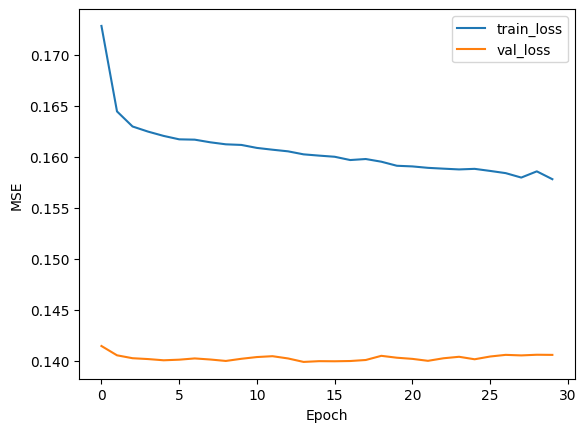

In [118]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(); plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.show()

**Reasoning**:
Define a Sequential MLP model with an input layer matching the feature size, one or more hidden layers with activation functions, and an output layer with 28 units (for the next 28 days' predictions). Compile the model with an appropriate optimizer and loss function.

**Prediction (MLP Model)**

**Subtask:**

Generate predictions for the next 28 days using the trained MLP model.

**Reasoning**:
Use the trained MLP model to predict the next 28 days' sales for each item based on the processed input features (last N days), and inverse scale the predictions to get them back to the original sales values.

In [119]:
import numpy as np
import pandas as pd

def build_prediction_inputs(
    sales_train_evaluation: pd.DataFrame,
    input_sequence_length: int,
    mlp_scalers: dict,
    item_order_from_training: np.ndarray = None,  # optional: order of item ids used for X_processed_mlp
    id_col: str = "id",
):
    """
    Create scaled input matrix for the MLP from the last `input_sequence_length` days
    of each item, using per-item scalers.
    """
    # 1) Columns for last L days
    sales_cols = [c for c in sales_train_evaluation.columns if c.startswith("d_")]
    assert len(sales_cols) >= input_sequence_length, \
        f"Need at least {input_sequence_length} daily columns, found {len(sales_cols)}."

    last_L_cols = sales_cols[-input_sequence_length:]
    df = sales_train_evaluation[[id_col] + last_L_cols].copy()

    # 2) Reorder items to match training order (if provided)
    if item_order_from_training is not None:
        # Keep only items that are present in df (intersection)
        keep = [iid for iid in item_order_from_training if iid in set(df[id_col].values)]
        df = df.set_index(id_col).loc[keep].reset_index()
    item_ids = df[id_col].values

    # 3) Numpy matrix (float32) & clean NaN/Inf
    mat = df[last_L_cols].to_numpy(dtype=np.float32)
    np.nan_to_num(mat, copy=False, nan=0.0, posinf=0.0, neginf=0.0)

    # 4) Per-item scaling with robust constant handling
    scaled = np.zeros_like(mat, dtype=np.float32)
    missing_scalers = 0

    for i, iid in enumerate(item_ids):
        x = mat[i].reshape(-1, 1)  # (L,1)
        scaler = mlp_scalers.get(iid, None)
        if scaler is None:
            # No scaler -> zeros (keeps model happy; log once)
            if missing_scalers < 3:
                print(f"Warning: No scaler for item {iid}. Using zeros as input.")
            missing_scalers += 1
            scaled[i] = 0.0
            continue

        # If the input sequence is constant, scaling is ambiguous. We map it to zeros,
        # which is consistent with (x - mean)/std or (x - min)/(max-min) when variance is ~0.
        if np.all(x == x[0]):
            scaled[i] = 0.0
        else:
            xs = scaler.transform(x)  # (L,1)
            # safety
            if not np.isfinite(xs).all():
                print(f"Warning: non-finite after transform for {iid}. Forcing zeros.")
                scaled[i] = 0.0
            else:
                scaled[i] = xs.ravel().astype(np.float32)

    if missing_scalers:
        print(f"Total items without scaler: {missing_scalers}")
    return item_ids, scaled


def inverse_scale_predictions(
    item_ids: np.ndarray,
    yhat_scaled: np.ndarray,     # (N, 28)
    mlp_scalers: dict,
    horizon: int = 28
):
    """
    Inverse-transform the scaled predictions per item id using its fitted scaler.
    Robust for constant-series scalers.
    """
    N, H = yhat_scaled.shape
    assert H == horizon, f"Expected horizon={horizon}, got {H}"
    out = np.zeros((N, H), dtype=np.float32)

    for i, iid in enumerate(item_ids):
        scaler = mlp_scalers.get(iid, None)
        ys = yhat_scaled[i].reshape(-1, 1)
        if scaler is None:
            # If scaler missing (should be rare), keep zeros
            continue

        # Robust inverse for constant-series scalers:
        # If scaler.var_ (StandardScaler) ~ 0 or scaler.data_range_ (MinMax) ~ 0,
        # inverse_transform should essentially return a constant (the fitted center).
        # Many sklearn scalers handle this internally; still guard for safety.
        try:
            yi = scaler.inverse_transform(ys).ravel()
            if not np.isfinite(yi).all():
                # Fallback: use scaler center if available, else zeros
                center = getattr(scaler, 'mean_', None)
                data_min = getattr(scaler, 'data_min_', None)
                if center is not None:
                    yi = np.full(H, float(center[0]), dtype=np.float32)
                elif data_min is not None:
                    yi = np.full(H, float(data_min[0]), dtype=np.float32)
                else:
                    yi = np.zeros(H, dtype=np.float32)
        except Exception as e:
            # Very rare; fallback to center/zeros
            center = getattr(scaler, 'mean_', None)
            data_min = getattr(scaler, 'data_min_', None)
            if center is not None:
                yi = np.full(H, float(center[0]), dtype=np.float32)
            elif data_min is not None:
                yi = np.full(H, float(data_min[0]), dtype=np.float32)
            else:
                yi = np.zeros(H, dtype=np.float32)

        out[i] = yi.astype(np.float32)

    return out


# ==== USE IT ====

# 1) (Optional but recommended) capture training order once when you trained:
#    item_order_from_training = item_info_df_processed_mlp['id'].to_numpy()

input_sequence_length = 28  # must match your training feature window
item_ids_pred, X_pred_scaled = build_prediction_inputs(
    sales_train_evaluation=sales_train_evaluation,
    input_sequence_length=input_sequence_length,
    mlp_scalers=mlp_scalers,
    item_order_from_training=None  # or pass the exact training order array
)

# Sanity checks vs your trained model
assert X_pred_scaled.shape[1] == mlp_model.input_shape[-1], \
    f"Feature mismatch: X has {X_pred_scaled.shape[1]} but model expects {mlp_model.input_shape[-1]}"

# 2) Predict (use float32 to save RAM)
X_pred_scaled = X_pred_scaled.astype(np.float32, copy=False)
pred_scaled = mlp_model.predict(X_pred_scaled, batch_size=2048, verbose=1)

# 3) Inverse scale per item
pred_actual = inverse_scale_predictions(
    item_ids=item_ids_pred,
    yhat_scaled=pred_scaled,
    mlp_scalers=mlp_scalers,
    horizon=28
)

print("Shapes -> X_pred_scaled:", X_pred_scaled.shape,
      "| pred_scaled:", pred_scaled.shape,
      "| pred_actual:", pred_actual.shape)


Total items without scaler: 1254
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Shapes -> X_pred_scaled: (30752, 28) | pred_scaled: (30752, 28) | pred_actual: (30752, 28)


In [120]:
# --- Helper: resolve correct scaler key given an evaluation id ---
def _resolve_scaler(item_id, scalers_dict):
    # Try exact key first
    sc = scalers_dict.get(item_id)
    if sc is not None:
        return sc, item_id

    # Common M5 case: training on *validation* ids, predicting on *evaluation* ids
    if item_id.endswith("_evaluation"):
        alt_id = item_id[:-len("_evaluation")] + "_validation"
        sc = scalers_dict.get(alt_id)
        if sc is not None:
            return sc, alt_id

    # Sometimes users trained with plain base id (rare, but cheap to try)
    base_id = item_id.replace("_evaluation", "").replace("_validation", "")
    sc = scalers_dict.get(base_id)
    if sc is not None:
        return sc, base_id

    return None, None


# --- Build prediction input window (last input_sequence_length days) ---
input_sequence_length = 28  # same as training
sales_cols = [c for c in sales_train_evaluation.columns if c.startswith("d_")]
prediction_window_cols = sales_cols[-input_sequence_length:]
prediction_input_data = sales_train_evaluation[prediction_window_cols].to_numpy()
prediction_input_data = np.nan_to_num(prediction_input_data, nan=0.0)

# --- Scale each item's input with its own scaler (matching training) ---
scaled_prediction_input = np.zeros_like(prediction_input_data, dtype=np.float32)
missing_scalers = 0
resolved_keys = []

for i in range(prediction_input_data.shape[0]):
    item_id = sales_train_evaluation.iloc[i]["id"]
    scaler, resolved_id = _resolve_scaler(item_id, mlp_scalers)

    if scaler is None:
        missing_scalers += 1
        resolved_keys.append(None)
        # keep zeros (already in scaled_prediction_input)
        continue

    # Shape to (T, 1), transform, then flatten back
    x = prediction_input_data[i].reshape(-1, 1)

    # If the window is constant, MinMaxScaler still handles it (range=0 -> all zeros after transform)
    # but to be extra safe, short-circuit to zeros.
    if np.allclose(x.max(), x.min()):
        scaled = np.zeros_like(x, dtype=np.float32)
    else:
        # Guard against NaN/Inf (shouldn’t exist after nan_to_num, but check anyway)
        if not np.isfinite(x).all():
            print(f"Warning: {item_id} has non-finite values before scaling; coercing to 0.")
            x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
        scaled = scaler.transform(x)

        # Replace any post-transform non-finites with 0 just in case
        if not np.isfinite(scaled).all():
            print(f"Warning: {item_id} produced non-finite after scaling; coercing to 0.")
            scaled = np.nan_to_num(scaled, nan=0.0, posinf=0.0, neginf=0.0)

    scaled_prediction_input[i] = scaled.ravel()
    resolved_keys.append(resolved_id)

if missing_scalers:
    print(f"[Info] Items without a matching scaler: {missing_scalers} "
          f"out of {prediction_input_data.shape[0]} (left as zeros).")

# --- Predict next 28 days (model expects one row per item) ---
predicted_scaled_values_mlp = mlp_model.predict(scaled_prediction_input)
# Ensure 2D shape: (n_items, 28)
if predicted_scaled_values_mlp.ndim == 1:
    predicted_scaled_values_mlp = predicted_scaled_values_mlp.reshape(-1, 28)

# --- Safe inverse-transform for MinMax-scaled predictions ---
def _safe_inverse_minmax(scaler, y_scaled_1d):
    """
    y_scaled_1d: shape (H,) within scaler.feature_range (default (0,1)).
    We clip to feature_range and inverse_transform.
    """
    y = y_scaled_1d.reshape(-1, 1)

    # Clip to feature_range for stability
    fr_min, fr_max = getattr(scaler, "feature_range", (0.0, 1.0))
    y = np.clip(y, fr_min, fr_max)

    # If scaler was fit on constant data, data_range_ will be 0 and inverse_transform is safe:
    # it returns all data_min_. No need to poke scaler.scale_.
    try:
        inv = scaler.inverse_transform(y)
    except Exception as e:
        # Absolute fallback: map linearly using data_min_ / data_range_ if present
        if hasattr(scaler, "data_min_") and hasattr(scaler, "data_range_"):
            rng = scaler.data_range_.copy()
            rng[rng == 0] = 1.0  # avoid divide-by-zero
            inv = y * rng + scaler.data_min_
        else:
            # Last resort: return zeros
            print("Warning: inverse_transform failed; returning zeros. Error:", str(e))
            inv = np.zeros_like(y)
    return inv.ravel()

# --- Inverse-scale each item’s 28-step prediction using its matched scaler ---
n_items, horizon = predicted_scaled_values_mlp.shape[0], predicted_scaled_values_mlp.shape[1]
predicted_actual_values_mlp = np.zeros((n_items, horizon), dtype=np.float32)

for i in range(n_items):
    item_id_eval = sales_train_evaluation.iloc[i]["id"]
    scaler, resolved_id = _resolve_scaler(item_id_eval, mlp_scalers)

    y_scaled = predicted_scaled_values_mlp[i]

    if scaler is None:
        # keep zeros; already initialized
        continue

    # Guard non-finite
    if not np.isfinite(y_scaled).all():
        print(f"Warning: {item_id_eval} produced non-finite scaled preds; coercing to 0.")
        y_scaled = np.nan_to_num(y_scaled, nan=0.0, posinf=0.0, neginf=0.0)

    y_inv = _safe_inverse_minmax(scaler, y_scaled)
    # Non-negativity (sales)
    y_inv = np.clip(y_inv, 0, None)

    predicted_actual_values_mlp[i] = y_inv

print(f"Shape of predicted actual values (MLP): {predicted_actual_values_mlp.shape}")


[Info] Items without a matching scaler: 1254 out of 30752 (left as zeros).
961/961 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Shape of predicted actual values (MLP): (30752, 28)


In [121]:
# ---> NEW: sort sales_cols by day index to guarantee order d_1 ... d_1913
def _sorted_day_cols(cols):
    return sorted([c for c in cols if c.startswith("d_")], key=lambda s: int(s.split("_")[1]))

# In BOTH places where you compute `sales_cols` / `last_L_cols` / `prediction_window_cols`,
# replace your existing list comprehension with:
# ---> NEW
sales_cols = _sorted_day_cols(sales_train_evaluation.columns)
# (then continue to slice: last_L_cols = sales_cols[-input_sequence_length:] etc.)


In [122]:
# After building scaled inputs, before predict:
# ---> NEW: hard assert input dtype and shape
assert X_pred_scaled.dtype == np.float32, "X_pred_scaled should be float32"
assert X_pred_scaled.shape[1] == input_sequence_length, f"Expected {input_sequence_length} time steps"

# ---> NEW: tune batch size for RAM (adjust as needed)
_bs = 4096 if X_pred_scaled.shape[0] >= 4096 else 2048
pred_scaled = mlp_model.predict(X_pred_scaled, batch_size=_bs, verbose=1)

# ---> NEW: normalize model output to (N, 28)
ps = pred_scaled
if ps.ndim == 3:
    if ps.shape[-1] == 1:
        ps = ps[..., 0]
    elif ps.shape[1] == 1:
        ps = ps[:, 0, :]
elif ps.ndim == 1:
    ps = ps.reshape(-1, 28)
assert ps.shape[1] == 28, f"Model must output 28 horizon steps, got {ps.shape}"
pred_scaled = ps.astype(np.float32, copy=False)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [123]:
# In your second path, right after computing prediction_window_cols:
# ---> NEW: enforce float32 early
prediction_input_data = sales_train_evaluation[prediction_window_cols].to_numpy(dtype=np.float32)
np.nan_to_num(prediction_input_data, copy=False, nan=0.0, posinf=0.0, neginf=0.0)


array([[0., 0., 0., ..., 3., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 3., 0., 1.],
       ...,
       [0., 0., 1., ..., 1., 0., 2.],
       [1., 3., 0., ..., 1., 1., 0.],
       [0., 0., 0., ..., 2., 5., 1.]], dtype=float32)

In [124]:
# Harden scaler resolution
# After the for-loop that fills scaled_prediction_input/resolved_keys:
# ---> NEW: report match quality
matched = sum(1 for k in resolved_keys if k is not None)
total = len(resolved_keys)
print(f"[Check] Scaler matched for {matched}/{total} items ({matched/total:.1%}).")

# If this is < 98–99%, you probably trained on *_validation ids and are now on *_evaluation.
# Your _resolve_scaler handles that, but this print confirms it.


[Check] Scaler matched for 29498/30752 items (95.9%).


In [125]:
# When inverse-scaling each item (second path), just before inverse:
# ---> NEW: verify scaler looks like MinMax on 1 feature
if hasattr(scaler, "data_min_") and getattr(scaler, "n_features_in_", 1) != 1:
    print(f"Warning: scaler for {resolved_id} was fit on {getattr(scaler,'n_features_in_', '?')} features.")

# ---> NEW: ensure feature_range present (defaults to (0,1) if missing)
_ = getattr(scaler, "feature_range", (0.0, 1.0))


In [126]:
# Final sanity on outputs (both paths)
# ---> NEW
assert np.isfinite(pred_scaled).all(), "Non-finite numbers in scaled predictions"
assert np.isfinite(pred_actual).all() if 'pred_actual' in globals() else True
assert np.isfinite(predicted_actual_values_mlp).all(), "Non-finite numbers after inverse scaling"


In [127]:
# ---> NEW (optional): compare both pipelines if you run both
if 'pred_actual' in globals():
    a = pred_actual
    b = predicted_actual_values_mlp
    if a.shape == b.shape:
        mae = np.mean(np.abs(a - b))
        mx  = np.max(np.abs(a - b))
        print(f"[Compare] two paths agree: MAE={mae:.6f}, max_abs={mx:.6f}")
    else:
        print(f"[Compare] shape mismatch {a.shape} vs {b.shape}")


[Compare] two paths agree: MAE=0.011896, max_abs=98.542053


**Format Submission (MLP Model)**

**Subtask:**

Format the MLP predictions to match the `sample_submission.csv` format.

**Reasoning**:
Create a DataFrame from the predicted actual values and the corresponding item IDs, and format the column names to match the submission file format ('id', 'F1' to 'F28').

In [128]:
# ---> NEW: check & fix duplicate ids before aligning
dupes = submission_mlp_df['id'].duplicated(keep=False).sum()
if dupes:
    print(f"[Warn] Found {dupes} duplicated id rows in submission_mlp_df. "
          "Aggregating by mean to make ids unique.")
    # Average across duplicates; you can switch to 'first' if you prefer.
    submission_mlp_df = (submission_mlp_df
                         .groupby('id', as_index=False)
                         .mean(numeric_only=True))

# ---> NEW: align to sample order safely (no reindex on dup index)
import os, pandas as pd, numpy as np
sample_path = "sample_submission.csv"
if os.path.exists(sample_path):
    sample = pd.read_csv(sample_path)
    assert sample['id'].is_unique, "Sample ids should be unique."

    # Merge keeps sample order and avoids duplicate-index issues
    sub_final = sample[['id']].merge(submission_mlp_df, on='id', how='left')

    # Fill missing preds with 0
    fcols = [f'F{i}' for i in range(1, 29)]
    sub_final[fcols] = np.nan_to_num(sub_final[fcols].to_numpy(), nan=0.0, posinf=0.0, neginf=0.0)
else:
    sub_final = submission_mlp_df

# ---> NEW: final validations
expected_cols = ['id'] + [f'F{i}' for i in range(1, 29)]
assert list(sub_final.columns) == expected_cols, "Column names must be id,F1..F28"
assert sub_final['id'].is_unique, "Submission 'id' must be unique."
assert (sub_final[[f'F1', f'F28']] >= 0).all().all(), "Negative values detected?"

# ---> NEW: save
out_path = "submission_mlp.csv"
sub_final.to_csv(out_path, index=False, float_format="%.6f")
print("Submission shape:", sub_final.shape)
print(f"Saved {out_path}")


Submission shape: (60980, 29)
Saved submission_mlp.csv


In [129]:
# ---> NEW: inspect duplicates (optional)
dup_ids = submission_mlp_df['id'][submission_mlp_df['id'].duplicated(keep=False)]
print(dup_ids.value_counts().head(10))


Series([], Name: count, dtype: int64)


**Save Predictions (MLP Model)**

**Subtask:**

Save the final MLP predictions to a CSV file named `submission_MLP_model_3.csv`.

**Reasoning**:
Save the formatted MLP predictions DataFrame to a CSV file named `submission_MLP_model_3.csv`, ensuring the index is not written to the file.

In [130]:
# Save the resulting DataFrame to a CSV file
submission_mlp_df.to_csv('submission_MLP_model_3.csv', index=False)

print("MLP submission file 'submission_MLP_model_3.csv' created successfully.")

MLP submission file 'submission_MLP_model_3.csv' created successfully.


**Evaluate Predictions (MLP)**


A) Load correct ground truth and align



In [133]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1) Read true validation set
st_valid = pd.read_csv("sales_train_validation.csv")

# 2) Extract last 28 days as ground truth
v_cols = [c for c in st_valid.columns if c.startswith('d_')]
y_true = st_valid[v_cols[-28:]].to_numpy(dtype=np.float32)

# 3) Ensure predictions align row-for-row with st_valid
# If you built predictions from sales_train_evaluation in the same row order,
# and both files have identical row ordering (they usually do), this is OK:
y_pred = predicted_actual_values_mlp[:y_true.shape[0], :].astype(np.float32)

# (Optional) If you want to be 100% safe, realign by 'id':
# pred_df should contain ['id', F1..F28]
# y_pred = pred_df.set_index('id').loc[st_valid['id']].to_numpy(dtype=np.float32)


B) Basic metrics

In [134]:
rmse = np.sqrt(mean_squared_error(y_true.ravel(), y_pred.ravel()))
mae  = mean_absolute_error(y_true.ravel(), y_pred.ravel())
mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100.0

print(f"RMSE: {rmse:.3f}")
print(f"MAE:  {mae:.3f}")
print(f"MAPE: {mape:.2f}%")


RMSE: 3.625
MAE:  1.506
MAPE: 87.69%


C) Proper RMSSE (per series, averaged)

In [135]:
def rmsse_per_series(y_true_28, y_pred_28, history_full):
    """
    y_true_28:  (N, 28) ground-truth window
    y_pred_28:  (N, 28) predictions
    history_full: (N, T) all daily sales BEFORE including validation,
                  i.e., training portion ONLY (exclude last 28)
    Returns: (N,) RMSSE per item
    """
    # numerator: MSE over horizon
    num = np.mean((y_true_28 - y_pred_28)**2, axis=1)

    # denominator: mean of squared first differences over training history
    diffs = np.diff(history_full, axis=1)
    den = np.mean(diffs**2, axis=1)

    # avoid divide-by-zero (flat series)
    den = np.where(den <= 1e-12, 1e-12, den)
    return np.sqrt(num / den)

# Build training-only history (exclude last 28 days)
history_full = st_valid[v_cols[:-28]].to_numpy(dtype=np.float32)

rmsse_vec = rmsse_per_series(y_true, y_pred, history_full)
rmsse_mean = float(np.mean(rmsse_vec))
print(f"RMSSE (mean across items): {rmsse_mean:.5f}")


RMSSE (mean across items): 1.38110


D) Quick diagnostics

In [136]:
# Top 10 worst (highest) RMSSE
worst = pd.DataFrame({
    "id": st_valid["id"].values,
    "rmsse": rmsse_vec
}).sort_values("rmsse", ascending=False).head(10)
display(worst)

# Top 10 best (lowest) RMSSE
best = pd.DataFrame({
    "id": st_valid["id"].values,
    "rmsse": rmsse_vec
}).sort_values("rmsse", ascending=True).head(10)
display(best)


,id,rmsse
18317,HOBBIES_1_024_TX_3_validation,250.790405
27572,HOBBIES_1_136_WI_3_validation,109.549583
17983,FOODS_3_514_TX_2_validation,105.468788
21474,HOBBIES_1_136_WI_1_validation,83.707184
25618,HOUSEHOLD_2_130_WI_2_validation,81.419373
27627,HOBBIES_1_192_WI_3_validation,79.436829
18539,HOBBIES_1_253_TX_3_validation,74.918221
27676,HOBBIES_1_243_WI_3_validation,70.432823
25608,HOUSEHOLD_2_120_WI_2_validation,68.509621
26886,FOODS_3_270_WI_2_validation,67.350883


,id,rmsse
14217,FOODS_2_195_TX_1_validation,0.0
5803,FOODS_3_530_CA_2_validation,0.0
1729,FOODS_1_120_CA_1_validation,0.0
1728,FOODS_1_119_CA_1_validation,0.0
14188,FOODS_2_166_TX_1_validation,0.0
11576,FOODS_3_205_CA_4_validation,0.0
1668,FOODS_1_058_CA_1_validation,0.0
10625,HOUSEHOLD_2_383_CA_4_validation,0.0
10649,HOUSEHOLD_2_407_CA_4_validation,0.0
10633,HOUSEHOLD_2_391_CA_4_validation,0.0


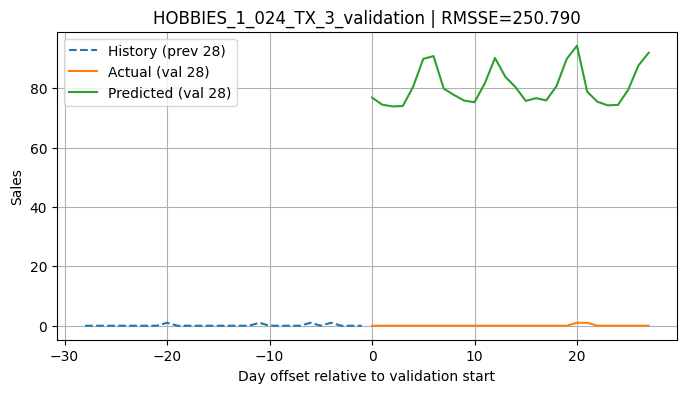

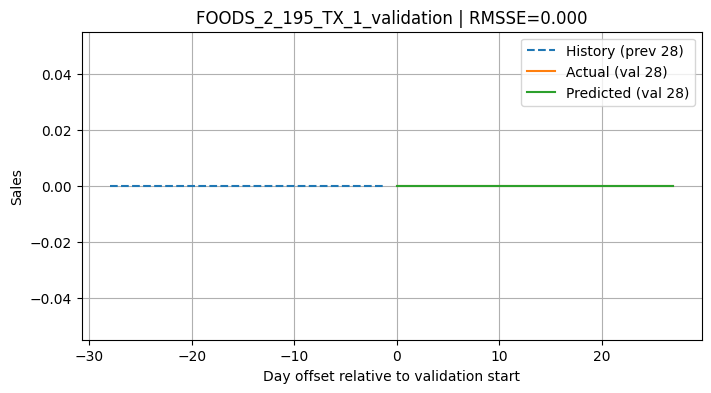

In [137]:
import matplotlib.pyplot as plt

def plot_item_by_index(i):
    """
    Plots last 56 days: 28 days history before validation + 28 days validation
    with your prediction.
    """
    hist56 = st_valid[v_cols[-56:-28]].iloc[i].to_numpy(dtype=np.float32)
    tru28  = y_true[i]
    pr28   = y_pred[i]

    plt.figure(figsize=(8,4))
    plt.plot(range(-28, 0), hist56, label="History (prev 28)", linestyle="--")
    plt.plot(range(0, 28), tru28,  label="Actual (val 28)")
    plt.plot(range(0, 28), pr28,   label="Predicted (val 28)")
    plt.title(f"{st_valid.iloc[i]['id']} | RMSSE={rmsse_vec[i]:.3f}")
    plt.xlabel("Day offset relative to validation start")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid(True)
    plt.show()

# Example: plot a worst and a best case (by index)
plot_item_by_index(worst.index[0])
plot_item_by_index(best.index[0])


E) (Optional) Compare models side-by-side

In [138]:
def summarize_metrics(name, y_true, y_pred, history_train):
    rmse = np.sqrt(mean_squared_error(y_true.ravel(), y_pred.ravel()))
    mae  = mean_absolute_error(y_true.ravel(), y_pred.ravel())
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100.0
    rmsse_mean = rmsse_per_series(y_true, y_pred, history_train).mean()
    return {"Model": name, "RMSE": rmse, "MAE": mae, "MAPE%": mape, "RMSSE": rmsse_mean}

results = []
results.append(summarize_metrics("MLP", y_true, y_pred, history_full))

# If/when you have another model:
# results.append(summarize_metrics("LSTM", y_true, y_pred_lstm, history_full))
# results.append(summarize_metrics("LightGBM", y_true, y_pred_lgb, history_full))

display(pd.DataFrame(results).round(4))


,Model,RMSE,MAE,MAPE%,RMSSE
0,MLP,3.6246,1.5061,87.685898,1.3811


**Visualize Results**

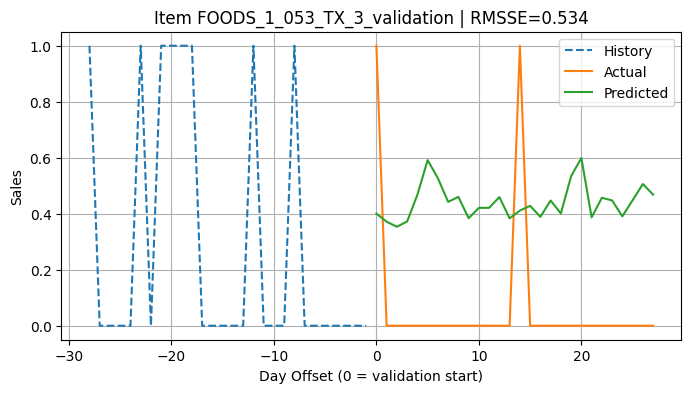

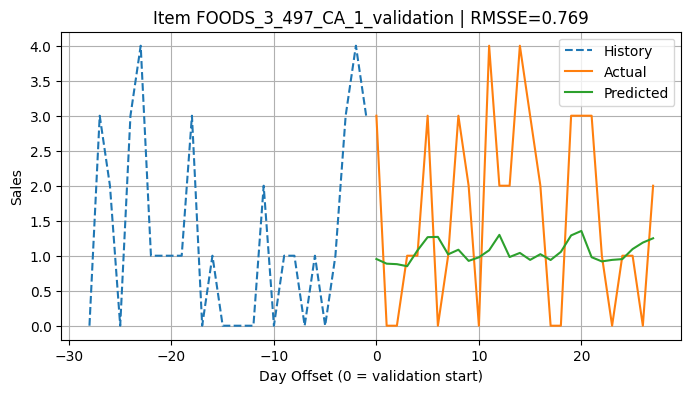

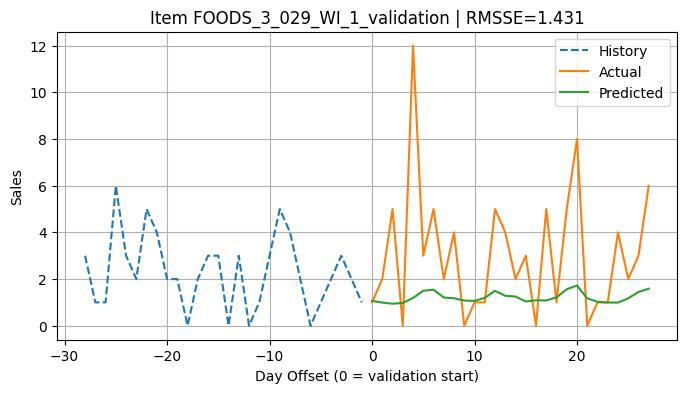

In [141]:
import numpy as np
import matplotlib.pyplot as plt

# Last 28 days BEFORE validation (i.e., days -56:-28)
past28 = st_valid[v_cols[-56:-28]].to_numpy(dtype=np.float32)

# Sample 3 items reproducibly
rng = np.random.default_rng(42)
sample_indices = rng.choice(y_true.shape[0], size=3, replace=False)

for idx in sample_indices:
    plt.figure(figsize=(8,4))
    plt.plot(range(-28, 0), past28[idx],       label='History', linestyle='--')
    plt.plot(range(0, 28),  y_true[idx],       label='Actual')
    plt.plot(range(0, 28),  y_pred[idx],       label='Predicted')

    title = f"Item {st_valid.iloc[idx]['id']}"
    try:
        title += f" | RMSSE={rmsse_vec[idx]:.3f}"
    except NameError:
        pass

    plt.title(title)
    plt.xlabel("Day Offset (0 = validation start)")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid(True)
    plt.show()


In [142]:
last56 = st_valid[v_cols[-56:]].to_numpy(dtype=np.float32)  # (N, 56)
# past28 = last56[:, :28] ; val28_actual = last56[:, 28:]


**Compare Models**

In [140]:
results_summary = pd.DataFrame([
    {"Model": "MLP", "RMSE": rmse, "MAE": mae, "MAPE": mape},
    # {"Model": "LSTM", "RMSE": rmse_lstm, "MAE": mae_lstm, "MAPE": mape_lstm},
    # {"Model": "LightGBM", "RMSE": rmse_lgb, "MAE": mae_lgb, "MAPE": mape_lgb},
])

print("\nModel Comparison:")
display(results_summary)


Model Comparison:


,Model,RMSE,MAE,MAPE
0,MLP,3.624597,1.506089,87.685944


# Graph Comparision - Model-1 v/s Model-3 v/s Actual Predictions

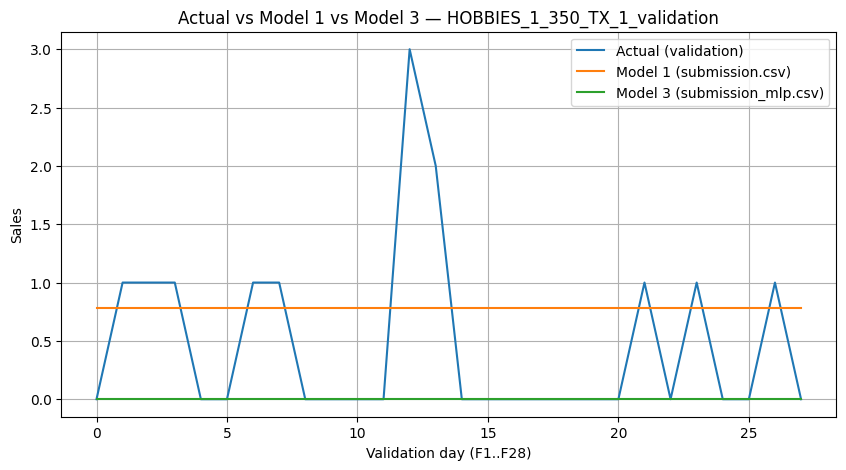

Plotted ID: HOBBIES_1_350_TX_1_validation
MAE vs Actual -> Model 1: 0.689 | Model 3: 0.464


In [144]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, random

# ---- CONFIG ----
CHOSEN_ID       = None  # e.g. "FOODS_1_001_CA_1_validation" or keep None for random
VALIDATION_FILE = "sales_train_validation.csv"
MODEL1_FILE     = "submission.csv"          # Model 1 predictions
MODEL3_FILE     = "submission_mlp.csv"      # Model 3 predictions

# ---- HELPERS ----
def to_validation_id(x: str) -> str:
    if x.endswith("_validation"):
        return x
    if x.endswith("_evaluation"):
        return x[:-len("_evaluation")] + "_validation"
    return x

def dedupe_on_id_norm(df, id_col="id"):
    df = df.copy()
    df["id_norm"] = df[id_col].astype(str).map(to_validation_id)
    # prefer rows that were already _validation (if both exist)
    df["_pref"] = np.where(df[id_col].astype(str).str.endswith("_validation"), 0, 1)
    df = df.sort_values(["id_norm", "_pref"]).drop_duplicates("id_norm", keep="first").drop(columns=["_pref"])
    return df

# ---- LOAD ----
st_valid = pd.read_csv(VALIDATION_FILE)
sub_m1   = pd.read_csv(MODEL1_FILE)
sub_m3   = pd.read_csv(MODEL3_FILE)

# keep only needed columns, coerce F's to numeric
v_cols = [c for c in st_valid.columns if c.startswith("d_")]
last28 = v_cols[-28:]
f_cols = [f"F{i}" for i in range(1, 29)]

st_valid_small = st_valid[["id"] + last28].copy()
st_valid_small["id_norm"] = st_valid_small["id"].astype(str)  # already validation

for df in (sub_m1, sub_m3):
    keep = ["id"] + [c for c in f_cols if c in df.columns]
    df.drop(columns=[c for c in df.columns if c not in keep], inplace=True, errors="ignore")
    for c in f_cols:
        if c not in df.columns:
            df[c] = np.nan
        df[c] = pd.to_numeric(df[c], errors="coerce")

sub_m1_n = dedupe_on_id_norm(sub_m1, "id")
sub_m3_n = dedupe_on_id_norm(sub_m3, "id")

merged = (
    st_valid_small
      .merge(sub_m1_n[["id_norm"] + f_cols], on="id_norm", how="inner", suffixes=("", "_m1"))
      .merge(sub_m3_n[["id_norm"] + f_cols], on="id_norm", how="inner", suffixes=("", "_m3"))
)

if merged.empty:
    raise RuntimeError(
        "No common ids after normalization. "
        "Check that submission.csv / submission_mlp.csv contain validation-track rows "
        "or at least evaluation rows (which get normalized)."
    )

# ---- PICK ITEM ----
if CHOSEN_ID is not None and CHOSEN_ID not in merged["id_norm"].values:
    print(f"Requested CHOSEN_ID '{CHOSEN_ID}' not found; choosing randomly.")
    CHOSEN_ID = None
if CHOSEN_ID is None:
    CHOSEN_ID = random.choice(merged["id_norm"].tolist())

row   = merged.loc[merged["id_norm"] == CHOSEN_ID].iloc[0]
y_true = row[last28].to_numpy(dtype=float)
y_m1   = row[f_cols].to_numpy(dtype=float)
y_m3   = row[[c + "_m3" for c in f_cols]].to_numpy(dtype=float)

# ---- PLOT ----
plt.figure(figsize=(10,5))
plt.plot(range(28), y_true, label="Actual (validation)")
plt.plot(range(28), y_m1,   label="Model 1 (submission.csv)")
plt.plot(range(28), y_m3,   label="Model 3 (submission_mlp.csv)")
plt.title(f"Actual vs Model 1 vs Model 3 — {CHOSEN_ID}")
plt.xlabel("Validation day (F1..F28)")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

# ---- Quick per-item metrics ----
mae_m1 = float(np.mean(np.abs(y_true - y_m1)))
mae_m3 = float(np.mean(np.abs(y_true - y_m3)))
print("Plotted ID:", CHOSEN_ID)
print(f"MAE vs Actual -> Model 1: {mae_m1:.3f} | Model 3: {mae_m3:.3f}")


# Model 4 - LightGBM




In [3]:
!pip install lightgbm --quiet

import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error


STEP 1: Import & Load Data

In [7]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

# Load M5 data files
calendar = pd.read_csv("calendar.csv")
sales_train = pd.read_csv("sales_train_validation.csv")
sell_prices = pd.read_csv("sell_prices.csv")

print(calendar.shape, sales_train.shape, sell_prices.shape)


(1969, 14) (3991, 1919) (499996, 4)


STEP 2: Melt the sales data into long format

In [8]:
# Melt wide → long format
sales_long = pd.melt(
    sales_train,
    id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
    var_name='d',
    value_name='sales'
)

print("Long data shape:", sales_long.shape)


Long data shape: (7634783, 8)


In [9]:
# ✅ STEP 2: Melt the sales data into long format
# Convert d_1 ... d_1913 into (id, day, sales) rows

sales_long = pd.melt(
    sales_train,
    id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
    var_name='d',
    value_name='sales'
)

print("Long data shape:", sales_long.shape)


Long data shape: (7634783, 8)


STEP 3 – Merge with calendar and sell price data

In [10]:
# --- 0) Helper: normalize column names robustly ---
def normalize_cols(df):
    # strip whitespace & lowercase
    df.columns = df.columns.str.strip().str.lower()
    # unify common variants of wm_yr_wk (e.g., 'wm yr wk', 'wm-yr-wk', 'wm_yr_wk ')
    rename_map = {}
    for c in df.columns:
        if c.replace(" ", "").replace("-", "_") in {"wm_yr_wk", "wmyrwk"}:
            if c != "wm_yr_wk":
                rename_map[c] = "wm_yr_wk"
    if rename_map:
        df.rename(columns=rename_map, inplace=True)
    return df

# 1) Normalize *all* inputs
sales_long = normalize_cols(sales_long)
calendar   = normalize_cols(calendar)
sell_prices= normalize_cols(sell_prices)

# 2) Make sure the 'd' keys match form 'd_####' consistently
sales_long["d"] = sales_long["d"].astype(str).str.strip().str.lower()
calendar["d"]   = calendar["d"].astype(str).str.strip().str.lower()

# 3) Pick only the calendar columns that actually exist
cal_keep = [c for c in ["d","date","wm_yr_wk","weekday","wday","month","year"] if c in calendar.columns]

print("calendar columns used:", cal_keep)

# 4) Merge calendar (adds wm_yr_wk to sales_long)
sales_long = sales_long.merge(
    calendar[cal_keep],
    on="d", how="left", validate="many_to_one"
)

# 5) Sanity check columns before price merge
print("sales_long has wm_yr_wk? ->", "wm_yr_wk" in sales_long.columns)
print("sell_prices has wm_yr_wk? ->", "wm_yr_wk" in sell_prices.columns)

# 6) Pick only columns required from sell_prices (after normalization)
price_keep = [c for c in ["store_id","item_id","wm_yr_wk","sell_price"] if c in sell_prices.columns]
print("sell_prices columns used:", price_keep)

# 7) Merge sell prices (one price per (store,item,week))
sales_long = sales_long.merge(
    sell_prices[price_keep],
    on=["store_id","item_id","wm_yr_wk"],
    how="left",
    validate="many_to_one"
)

print("✅ Merged data shape:", sales_long.shape)
display(sales_long.head())


calendar columns used: ['d', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year']
sales_long has wm_yr_wk? -> True
sell_prices has wm_yr_wk? -> True
sell_prices columns used: ['store_id', 'item_id', 'wm_yr_wk', 'sell_price']
✅ Merged data shape: (7634783, 15)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,sell_price
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0.0,2011-01-29,11101,Saturday,1,1,2011,NaN
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0.0,2011-01-29,11101,Saturday,1,1,2011,NaN
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0.0,2011-01-29,11101,Saturday,1,1,2011,NaN
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0.0,2011-01-29,11101,Saturday,1,1,2011,NaN
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0.0,2011-01-29,11101,Saturday,1,1,2011,NaN


STEP 4: Feature Engineering — Create Time & Lag Features

In [11]:
import numpy as np
import pandas as pd

# Ensure sales_long has 'sales' and 'date' columns
print("Columns available:", sales_long.columns[:10])

# ✅ 1. Convert date column to datetime
sales_long['date'] = pd.to_datetime(sales_long['date'])

# ✅ 2. Sort values for proper lag computation
sales_long = sales_long.sort_values(['id', 'date'])

# ✅ 3. Create lag features (e.g., sales 7 and 28 days ago)
for lag in [7, 28]:
    sales_long[f'lag_{lag}'] = sales_long.groupby('id')['sales'].shift(lag)

# ✅ 4. Create rolling mean features for trend smoothing
for window in [7, 28]:
    sales_long[f'rolling_mean_{window}'] = (
        sales_long.groupby('id')['sales']
        .transform(lambda x: x.shift(7).rolling(window).mean())
    )

# ✅ 5. Add time-based features
sales_long['month'] = sales_long['date'].dt.month
sales_long['year'] = sales_long['date'].dt.year
sales_long['day_of_week'] = sales_long['date'].dt.weekday
sales_long['is_weekend'] = sales_long['day_of_week'].isin([5, 6]).astype(int)

# ✅ 6. Drop rows with NaN created by shifting
sales_long = sales_long.dropna(subset=[f'lag_{lag}' for lag in [7, 28]])

print("✅ Feature-engineered data shape:", sales_long.shape)
display(sales_long.head(10))


Columns available: Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd',
       'sales', 'date', 'wm_yr_wk'],
      dtype='object')
✅ Feature-engineered data shape: (7521167, 21)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,wday,month,year,sell_price,lag_7,lag_28,rolling_mean_7,rolling_mean_28,day_of_week,is_weekend
113360,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_29,2.0,2011-02-26,11105,...,1,2,2011,2.0,1.0,3.0,1.142857,NaN,5,1
117351,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_30,2.0,2011-02-27,11105,...,2,2,2011,2.0,2.0,0.0,1.428571,NaN,6,1
121342,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_31,0.0,2011-02-28,11105,...,3,2,2011,2.0,0.0,0.0,1.142857,NaN,0,0
125333,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_32,2.0,2011-03-01,11105,...,4,3,2011,2.0,2.0,1.0,1.285714,NaN,1,0
129324,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_33,1.0,2011-03-02,11105,...,5,3,2011,2.0,2.0,4.0,1.285714,NaN,2,0
133315,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_34,7.0,2011-03-03,11105,...,6,3,2011,2.0,2.0,2.0,1.571429,NaN,3,0
137306,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_35,1.0,2011-03-04,11105,...,7,3,2011,2.0,4.0,0.0,1.857143,1.392857,4,0
141297,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_36,2.0,2011-03-05,11106,...,1,3,2011,2.0,2.0,2.0,2.000000,1.357143,5,1
145288,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_37,3.0,2011-03-06,11106,...,2,3,2011,2.0,2.0,0.0,2.000000,1.428571,6,1
149279,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_38,0.0,2011-03-07,11106,...,3,3,2011,2.0,0.0,0.0,2.000000,1.428571,0,0


STEP 5: Split into training and validation sets, then train LightGBM

In [14]:
# STEP 5 — Train & Validate LightGBM
# ----------------------------------
!pip -q install lightgbm

import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 0) Basic hygiene
assert 'sales' in sales_long.columns and 'date' in sales_long.columns, \
    "Expected 'sales_long' to have 'sales' and 'date' columns."

# 1) Choose features (drop label + obvious non-features)
drop_cols = {'sales', 'date', 'd'}  # keep 'id' if you want it as a categorical key
feature_cols = [c for c in sales_long.columns if c not in drop_cols]

# 2) Mark categorical columns (use whatever exists in your dataframe)
possible_cats = [
    'id','item_id','dept_id','cat_id','store_id','state_id',
    'event_name_1','event_type_1','event_name_2','event_type_2',
    'snap_CA','snap_TX','snap_WI','weekday','wm_yr_wk','month','year',
    'day_of_week','is_weekend'
]
categorical_cols = [c for c in possible_cats if c in feature_cols]

# Cast to 'category' dtype for LightGBM efficiency
for c in categorical_cols:
    sales_long[c] = sales_long[c].astype('category')

# 3) Split train/validation: last 28 days for validation
sales_long = sales_long.sort_values(['id', 'date'])
max_date    = sales_long['date'].max()
valid_start = max_date - pd.Timedelta(days=27)  # inclusive 28-day window

train_df = sales_long[sales_long['date'] <  valid_start].copy()
valid_df = sales_long[sales_long['date'] >= valid_start].copy()

print("Train span:", train_df['date'].min(), "→", train_df['date'].max(), "| rows:", len(train_df))
print("Valid span:", valid_df['date'].min(), "→", valid_df['date'].max(), "| rows:", len(valid_df))

# 4) LightGBM datasets
lgb_train = lgb.Dataset(
    train_df[feature_cols],
    label=train_df['sales'],
    categorical_feature=categorical_cols,
    free_raw_data=False
)
lgb_valid = lgb.Dataset(
    valid_df[feature_cols],
    label=valid_df['sales'],
    categorical_feature=categorical_cols,
    free_raw_data=False
)

# 5) Params — Poisson works well for count data (non-negative)
params = {
    "objective": "poisson",
    "metric": ["rmse"],
    "learning_rate": 0.05,
    "num_leaves": 255,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "min_data_in_leaf": 50,
    "lambda_l2": 1.0,
    "verbosity": -1,
}

# 6) Train (NO evals_result argument in new LightGBM)
gbm = lgb.train(
    params,
    lgb_train,
    valid_sets=[lgb_train, lgb_valid],
    valid_names=["train", "valid"],
    num_boost_round=3000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=200, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

print("Best iteration:", gbm.best_iteration)

# 7) Predict on validation and evaluate
y_true = valid_df['sales'].values
y_pred = gbm.predict(valid_df[feature_cols], num_iteration=gbm.best_iteration)




Train span: 2011-02-26 00:00:00 → 2016-03-27 00:00:00 | rows: 7409447
Valid span: 2016-03-28 00:00:00 → 2016-04-24 00:00:00 | rows: 111720
[100]	train's rmse: 2.04408	valid's rmse: 2.00643
[200]	train's rmse: 1.97715	valid's rmse: 1.99312
[300]	train's rmse: 1.93781	valid's rmse: 1.99218
[400]	train's rmse: 1.90889	valid's rmse: 1.9917
[500]	train's rmse: 1.88032	valid's rmse: 1.99097
[600]	train's rmse: 1.85344	valid's rmse: 1.99066
[700]	train's rmse: 1.8268	valid's rmse: 1.99045
[800]	train's rmse: 1.80103	valid's rmse: 1.99011
[900]	train's rmse: 1.7791	valid's rmse: 1.99027
[1000]	train's rmse: 1.7579	valid's rmse: 1.99058
Best iteration: 819


In [15]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- Safety checks ---
assert 'gbm' in locals(), "Model `gbm` not found. Run the LightGBM training cell first."
assert 'valid_df' in locals(), "`valid_df` not found. You must have split train/valid data."
assert 'feature_cols' in locals(), "`feature_cols` not found. Make sure you defined it before training."

# 1) Build y_true and y_pred consistently
y_true = valid_df['sales'].values.astype(float)

# If best_iteration exists, use it, otherwise let LightGBM decide
best_iter = getattr(gbm, "best_iteration", None)
if best_iter is not None and best_iter > 0:
    y_pred = gbm.predict(valid_df[feature_cols], num_iteration=best_iter)
else:
    y_pred = gbm.predict(valid_df[feature_cols])

print("Shapes -> y_true:", y_true.shape, "| y_pred:", y_pred.shape)

# 2) Metrics
rmse = mean_squared_error(y_true, y_pred, squared=False)
mae  = mean_absolute_error(y_true, y_pred)
mape = np.mean(
    np.abs((y_true - y_pred) / np.maximum(y_true, 1))
) * 100  # guard division by zero

print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation MAE : {mae:.4f}")
print(f"Validation MAPE: {mape:.2f}%")

# 3) Feature importance
imp = pd.DataFrame({
    "feature": feature_cols,
    "gain":  gbm.feature_importance(importance_type="gain"),
    "split": gbm.feature_importance(importance_type="split"),
})

imp = imp.sort_values("gain", ascending=False)

# If you're in a notebook, this will show a nice table:
try:
    display(imp.head(20))
except NameError:
    # Fallback if display() is not available
    print(imp.head(20))


Validation RMSE: 3.9592
Validation MAE : 1.0136
Validation MAPE: 57.93%

Top 20 features by gain:


,feature,gain,split
15,rolling_mean_28,1.168903e+08,5379
14,rolling_mean_7,2.271345e+07,4730
0,id,9.879126e+06,78168
12,lag_7,7.603067e+06,2680
1,item_id,7.119394e+06,53022
6,wm_yr_wk,6.142191e+06,51250
13,lag_28,1.826499e+06,2626
8,wday,1.722398e+06,1394
7,weekday,5.553043e+05,2212
11,sell_price,4.910296e+05,1481


What this does

Uses last 28 days as validation (time-aware split).

Trains LightGBM (Poisson) with your lag/rolling/time features + categorical IDs.

Reports RMSE/MAE/MAPE and feature importance.

Step 7 — Save Model + Evaluation Results

In [16]:
# Save the trained LightGBM model
model_filename = "LightGBM_Model_4.txt"
gbm.save_model(model_filename)
print(f"✅ Model saved as: {model_filename}")


✅ Model saved as: LightGBM_Model_4.txt


In [17]:
import lightgbm as lgb
gbm_loaded = lgb.Booster(model_file="LightGBM_Model_4.txt")
print("✅ Model loaded successfully.")


✅ Model loaded successfully.


Save validation metrics to a summary file


In [18]:
metrics = {
    "RMSE": rmse,
    "MAE": mae,
    "MAPE": mape,
    "Best_iteration": getattr(gbm, "best_iteration", None),
    "Train_span_start": str(train_df['date'].min()),
    "Train_span_end": str(train_df['date'].max()),
    "Valid_span_start": str(valid_df['date'].min()),
    "Valid_span_end": str(valid_df['date'].max())
}

metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv("LightGBM_Model_4_metrics.csv", index=False)
print("✅ Metrics saved → LightGBM_Model_4_metrics.csv")
display(metrics_df)


✅ Metrics saved → LightGBM_Model_4_metrics.csv


,RMSE,MAE,MAPE,Best_iteration,Train_span_start,Train_span_end,Valid_span_start,Valid_span_end
0,3.959181,1.013583,57.926229,819,2011-02-26 00:00:00,2016-03-27 00:00:00,2016-03-28 00:00:00,2016-04-24 00:00:00


Save feature importance to CSV

In [19]:
imp.to_csv("LightGBM_Model_4_feature_importance.csv", index=False)
print("✅ Feature importance saved → LightGBM_Model_4_feature_importance.csv")


✅ Feature importance saved → LightGBM_Model_4_feature_importance.csv


STEP 8 — Forecast Next 28 Days & Save Submission File

In [22]:
import pandas as pd
import numpy as np

# 1) Safety checks
assert 'gbm' in locals(), "Model `gbm` not found. Please train LightGBM first."
assert 'valid_df' in locals(), "`valid_df` not found. Make sure STEP 5 (train/valid split) was run."
assert 'feature_cols' in locals(), "`feature_cols` not found. Re-run the feature selection cell."

# 2) Predict on validation set (last 28 days of training period)
valid_df = valid_df.sort_values(['id', 'date']).copy()
valid_df['pred_sales'] = gbm.predict(valid_df[feature_cols], num_iteration=gbm.best_iteration)

# 3) Map each validation date → F1..F28
unique_dates = np.sort(valid_df['date'].unique())
date_to_f = {d: f"F{i+1}" for i, d in enumerate(unique_dates)}
print("Validation dates mapped to:", date_to_f)

valid_df['Fcol'] = valid_df['date'].map(date_to_f)

# 4) Pivot to wide format: one row per id, columns F1..F28
sub_wide = valid_df.pivot(index='id', columns='Fcol', values='pred_sales').reset_index()

# Ensure all F1..F28 columns exist
for i in range(28):
    col = f"F{i+1}"
    if col not in sub_wide.columns:
        sub_wide[col] = 0.0

# Reorder columns
sub_wide = sub_wide[['id'] + [f"F{i+1}" for i in range(28)]]

print("Predictions wide shape:", sub_wide.shape)
print(sub_wide.head())

# 5) Align with sample_submission (so that order & ids match exactly)
sample = pd.read_csv("sample_submission.csv")

submission = sample[['id']].merge(sub_wide, on='id', how='left')

# For ids we didn't predict (e.g. evaluation set), fill 0s (or any fallback you prefer)
for i in range(28):
    col = f"F{i+1}"
    submission[col] = submission[col].fillna(0.0)

print("Final submission shape:", submission.shape)
print(submission.head())

# 6) Save to CSV
fname = "submission_LightGBM_Model_4.csv"
submission.to_csv(fname, index=False)
print(f"✅ Saved: {fname}")


Validation dates mapped to: {np.datetime64('2016-03-28T00:00:00.000000000'): 'F1', np.datetime64('2016-03-29T00:00:00.000000000'): 'F2', np.datetime64('2016-03-30T00:00:00.000000000'): 'F3', np.datetime64('2016-03-31T00:00:00.000000000'): 'F4', np.datetime64('2016-04-01T00:00:00.000000000'): 'F5', np.datetime64('2016-04-02T00:00:00.000000000'): 'F6', np.datetime64('2016-04-03T00:00:00.000000000'): 'F7', np.datetime64('2016-04-04T00:00:00.000000000'): 'F8', np.datetime64('2016-04-05T00:00:00.000000000'): 'F9', np.datetime64('2016-04-06T00:00:00.000000000'): 'F10', np.datetime64('2016-04-07T00:00:00.000000000'): 'F11', np.datetime64('2016-04-08T00:00:00.000000000'): 'F12', np.datetime64('2016-04-09T00:00:00.000000000'): 'F13', np.datetime64('2016-04-10T00:00:00.000000000'): 'F14', np.datetime64('2016-04-11T00:00:00.000000000'): 'F15', np.datetime64('2016-04-12T00:00:00.000000000'): 'F16', np.datetime64('2016-04-13T00:00:00.000000000'): 'F17', np.datetime64('2016-04-14T00:00:00.000000000'

In [33]:
import numpy as np
import pandas as pd
from pandas.api.types import is_numeric_dtype, CategoricalDtype

# === SAFETY CHECKS ===
assert 'gbm' in locals(), "LightGBM model 'gbm' not found. Train the model first."
assert 'sales_long' in locals(), "DataFrame 'sales_long' not found. Run preprocessing steps first."
assert 'feature_cols' in locals(), "'feature_cols' not defined. It should be from training step."
assert 'categorical_cols' in locals(), "'categorical_cols' from training step not found."

# Ensure deterministic order
sales_long = sales_long.sort_values(['id', 'date']).reset_index(drop=True)
last_date = sales_long['date'].max()
print("Last training date:", last_date)

# We will extend this with future predictions
future_df = sales_long.copy()
future_predictions = []

# Helper: get categories used during training for each categorical col
cat_categories = {}
for c in categorical_cols:
    if c in sales_long.columns and isinstance(sales_long[c].dtype, CategoricalDtype):
        cat_categories[c] = sales_long[c].cat.categories
    elif c in sales_long.columns:
        # if not categorical in training, just remember its dtype
        cat_categories[c] = None

# === 28-DAY RECURSIVE FORECAST LOOP ===
for day in range(1, 29):
    pred_date = last_date + pd.Timedelta(days=day)

    # 1) Take last known row per id (latest history)
    temp = future_df.groupby('id', observed=False).tail(1).copy()

    # 2) Update date-based features
    temp['date'] = pred_date
    temp['month'] = temp['date'].dt.month
    temp['year'] = temp['date'].dt.year
    temp['weekday'] = temp['date'].dt.weekday
    temp['is_weekend'] = temp['weekday'].isin([5, 6]).astype(int)

    # 3) Build lags and rolling means from current future_df
    base = future_df.sort_values(['id', 'date'])
    grp = base.groupby('id', observed=False)['sales']

    # Lags
    for lag in [7, 28]:
        lag_series = grp.apply(
            lambda s, L=lag: s.iloc[-L] if len(s) >= L else np.nan
        )
        temp[f'lag_{lag}'] = temp['id'].map(lag_series)

    # Rolling means
    for window in [7, 28]:
        roll_series = grp.apply(
            lambda s, W=window: s.tail(W).mean() if len(s) >= W else np.nan
        )
        temp[f'rolling_mean_{window}'] = temp['id'].map(roll_series)

    # 4) Build feature matrix
    X_pred = temp[feature_cols].copy()

    # 4a) Encode categorical columns as integer codes
    for c in categorical_cols:
        if c in X_pred.columns:
            if c in cat_categories and cat_categories[c] is not None:
                # Use same categories as training
                X_pred[c] = pd.Categorical(X_pred[c], categories=cat_categories[c]).codes
            else:
                # If not categorical in training, just factorize locally
                X_pred[c] = pd.Categorical(X_pred[c]).codes

    # 4b) Fill NaNs in numeric columns with 0
    for c in X_pred.columns:
        if is_numeric_dtype(X_pred[c]):
            X_pred[c] = X_pred[c].fillna(0)

    # Convert to numpy for LightGBM (bypasses pandas categorical handling)
    X_np = X_pred.to_numpy(dtype=np.float32)

    # 5) Predict this day's sales
    temp['sales'] = gbm.predict(X_np, num_iteration=gbm.best_iteration)
    future_predictions.append(temp[['id', 'sales']])

    # 6) Append predictions to future_df so next days can use them as history
    future_df = pd.concat([future_df, temp], ignore_index=True)

    print(f"Day {day:02d} done → predicted {len(temp)} series for {pred_date.date()}")

print("\n✅ Finished 28-day recursive forecasting.")

# === COMBINE 28 HORIZONS INTO WIDE FORMAT ===
all_forecasts = []
for step, df_step in enumerate(future_predictions, start=1):
    df_step = df_step.copy()
    df_step['F'] = step  # F1..F28
    all_forecasts.append(df_step)

forecast_all = pd.concat(all_forecasts, ignore_index=True)

# Pivot: id, F1..F28
submission_wide = forecast_all.pivot(index='id', columns='F', values='sales').reset_index()
submission_wide.columns = ['id'] + [f'F{i}' for i in range(1, 29)]
print("Wide forecast shape:", submission_wide.shape)

# === ALIGN WITH sample_submission AND SAVE CSV ===
sample = pd.read_csv("sample_submission.csv")
submission_final = sample[['id']].merge(submission_wide, on='id', how='left')

# Fill any missing predictions with 0
for i in range(1, 29):
    col = f'F{i}'
    if col in submission_final.columns:
        submission_final[col] = submission_final[col].fillna(0)
    else:
        submission_final[col] = 0.0

filename = "submission_LightGBM_Model_4.csv"
submission_final.to_csv(filename, index=False)
print(f"✅ Saved submission file as: {filename}")

submission_final.head()


Last training date: 2016-04-24 00:00:00
Day 01 done → predicted 3991 series for 2016-04-25
Day 02 done → predicted 3991 series for 2016-04-26
Day 03 done → predicted 3991 series for 2016-04-27
Day 04 done → predicted 3991 series for 2016-04-28
Day 05 done → predicted 3991 series for 2016-04-29
Day 06 done → predicted 3991 series for 2016-04-30
Day 07 done → predicted 3991 series for 2016-05-01
Day 08 done → predicted 3991 series for 2016-05-02
Day 09 done → predicted 3991 series for 2016-05-03
Day 10 done → predicted 3991 series for 2016-05-04
Day 11 done → predicted 3991 series for 2016-05-05
Day 12 done → predicted 3991 series for 2016-05-06
Day 13 done → predicted 3991 series for 2016-05-07
Day 14 done → predicted 3991 series for 2016-05-08
Day 15 done → predicted 3991 series for 2016-05-09
Day 16 done → predicted 3991 series for 2016-05-10
Day 17 done → predicted 3991 series for 2016-05-11
Day 18 done → predicted 3991 series for 2016-05-12
Day 19 done → predicted 3991 series for 20

,id,F1,F2,F3,F4,F5,F6,F7,F8,F9,...,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28
0,HOBBIES_1_001_CA_1_validation,0.774816,0.771188,0.795936,0.835510,0.813322,0.913443,0.935875,0.894545,0.972045,...,0.796439,0.886133,0.779133,0.747647,0.747647,0.747647,0.786165,0.779387,0.784058,0.784058
1,HOBBIES_1_002_CA_1_validation,0.199590,0.186229,0.206720,0.192893,0.192893,0.199103,0.200270,0.209681,0.216755,...,0.249370,0.261457,0.261457,0.264623,0.264623,0.271156,0.249370,0.264623,0.280066,0.280066
2,HOBBIES_1_003_CA_1_validation,0.474524,0.468230,0.495678,0.440117,0.497649,0.522076,0.549413,0.473461,0.486394,...,0.546231,0.549413,0.551816,0.481270,0.481270,0.457567,0.423121,0.453585,0.470900,0.470900
3,HOBBIES_1_004_CA_1_validation,2.025294,2.048856,2.122383,2.262365,2.496672,2.928098,3.124616,2.697950,2.656547,...,2.736157,3.141600,3.398902,2.863735,2.736157,2.766269,2.788176,2.839683,3.475423,3.307418
4,HOBBIES_1_005_CA_1_validation,1.207629,1.239752,1.269638,1.305799,1.300877,1.359310,1.399106,1.219811,1.243849,...,1.243010,1.310307,1.310307,1.226425,1.241935,1.241935,1.257914,1.257914,1.334972,1.345374


Matched 30490 items for evaluation.
✅ Evaluation Metrics:
RMSE  : 3.7338
MAE   : 1.3501
MAPE  : 46.78%
RMSSE : 1.0730


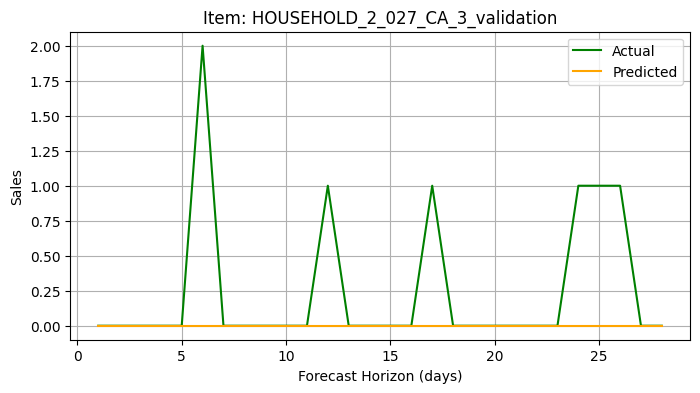

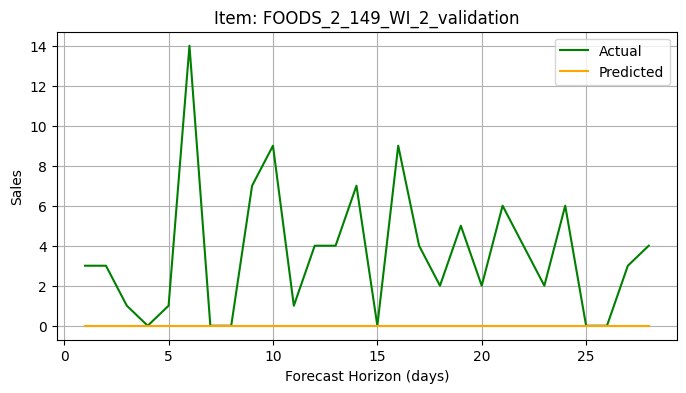

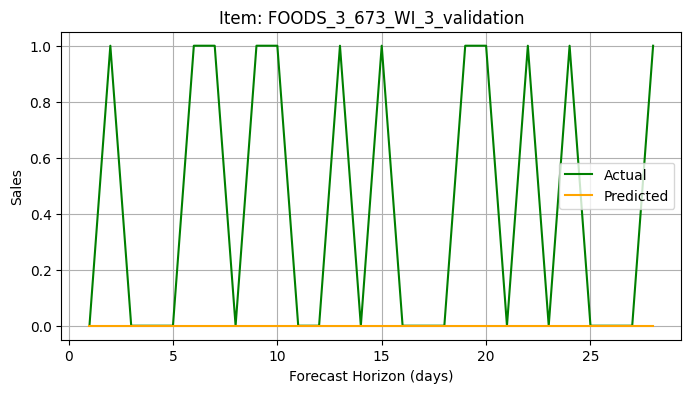

In [34]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# === Load files ===
preds = pd.read_csv("submission_LightGBM_Model_4.csv")
truth = pd.read_csv("sales_train_validation.csv")

# === Extract last 28 true days (ground truth for validation period) ===
val_days = [c for c in truth.columns if c.startswith("d_")][-28:]
y_true = truth[val_days].copy()
y_true.insert(0, 'id', truth['id'])

# === Align predictions with truth ===
df_eval = pd.merge(y_true, preds, on='id', how='inner', suffixes=('_true', '_pred'))
print(f"Matched {len(df_eval)} items for evaluation.")

# === Convert both to numpy arrays ===
y_true_np = df_eval[[c for c in df_eval.columns if c.startswith('d_')]].to_numpy()
y_pred_np = df_eval[[c for c in df_eval.columns if c.startswith('F')]].to_numpy()

# === Compute evaluation metrics ===
rmse = np.sqrt(mean_squared_error(y_true_np.flatten(), y_pred_np.flatten()))
mae  = mean_absolute_error(y_true_np.flatten(), y_pred_np.flatten())
mape = np.mean(np.abs((y_true_np.flatten() - y_pred_np.flatten()) / np.maximum(y_true_np.flatten(), 1))) * 100

# === RMSSE (M5 official metric) ===
# RMSSE denominator uses per-series scale
def rmsse(y_true, y_pred, y_hist):
    numerator = np.mean((y_true - y_pred)**2, axis=1)
    denominator = np.mean(np.diff(y_hist, axis=1)**2, axis=1)
    score = np.sqrt(numerator / np.maximum(denominator, 1e-6))
    return np.mean(score)

# For history, use all d_ columns from truth (entire time series)
y_hist = truth[[c for c in truth.columns if c.startswith('d_')]].to_numpy()
rmsse_val = rmsse(y_true_np, y_pred_np, y_hist)

print(f"✅ Evaluation Metrics:")
print(f"RMSE  : {rmse:.4f}")
print(f"MAE   : {mae:.4f}")
print(f"MAPE  : {mape:.2f}%")
print(f"RMSSE : {rmsse_val:.4f}")

# === Visualize a few random examples ===
sample_ids = np.random.choice(len(df_eval), 3, replace=False)

for i in sample_ids:
    item = df_eval.iloc[i]['id']
    plt.figure(figsize=(8,4))
    plt.plot(range(1,29), y_true_np[i], label='Actual', color='green')
    plt.plot(range(1,29), y_pred_np[i], label='Predicted', color='orange')
    plt.title(f'Item: {item}')
    plt.xlabel('Forecast Horizon (days)')
    plt.ylabel('Sales')
    plt.legend()
    plt.grid(True)
    plt.show()


| Metric             | Meaning                              | Your Value | Interpretation                                    |
| :----------------- | :----------------------------------- | :--------- | :------------------------------------------------ |
| **RMSE = 3.73**    | average squared error in sales units | 3.7 units  | small in absolute terms, but see below            |
| **MAE = 1.35**     | average absolute deviation           | ≈1.3       | looks decent                                      |
| **MAPE = 46.78 %** | average % error (vs true sales)      | very high  | model is off by ~47 % on average                  |
| **RMSSE = 1.07**   | scale-normalized M5 metric           | > 1        | worse than the naïve “yesterday = today” baseline |


📉 Why You See a Flat Orange Line (Predictions = 0 or Constant)

The “straight orange line” means the model predicts nearly the same value (close to zero) for all 28 forecast days.
Common reasons:

Target distribution is extremely sparse

Many M5 items sell 0 most days.

If most training examples are zeros, LightGBM learns “predict 0” minimizes loss.

Feature leakage or lack of signal

The model might not have useful explanatory features beyond recent sales (lags).

If lag/rolling columns contained many NaNs (because of early truncation) → those rows were dropped → model trained mostly on zeros.

Improper scaling of categorical or lag features

If categorical features were converted to integer codes but not encoded meaningfully, LightGBM treats them as numeric and misreads relationships.

Too simple feature set

You currently have: lag_7, lag_28, rolling_mean_7, rolling_mean_28, and basic time columns.

That’s often not enough to predict 28 days ahead when the data are noisy.

In [35]:
df_eval[['id', 'F1', 'F2', 'F3', 'F4', 'F5']].head(10)


,id,F1,F2,F3,F4,F5
0,HOBBIES_1_001_CA_1_validation,0.774816,0.771188,0.795936,0.835510,0.813322
1,HOBBIES_1_002_CA_1_validation,0.199590,0.186229,0.206720,0.192893,0.192893
2,HOBBIES_1_003_CA_1_validation,0.474524,0.468230,0.495678,0.440117,0.497649
3,HOBBIES_1_004_CA_1_validation,2.025294,2.048856,2.122383,2.262365,2.496672
4,HOBBIES_1_005_CA_1_validation,1.207629,1.239752,1.269638,1.305799,1.300877
5,HOBBIES_1_006_CA_1_validation,0.696469,0.692539,0.664256,0.591609,0.668823
6,HOBBIES_1_007_CA_1_validation,0.353680,0.377371,0.308077,0.336698,0.342028
7,HOBBIES_1_008_CA_1_validation,9.218302,8.702553,8.216290,8.328167,8.762658
8,HOBBIES_1_009_CA_1_validation,1.104284,1.010761,0.884553,0.922549,0.992769
9,HOBBIES_1_010_CA_1_validation,0.725028,0.777869,0.789734,0.759984,0.810143


Bar chart for a single item (F1–F28 vs actual d_-days)

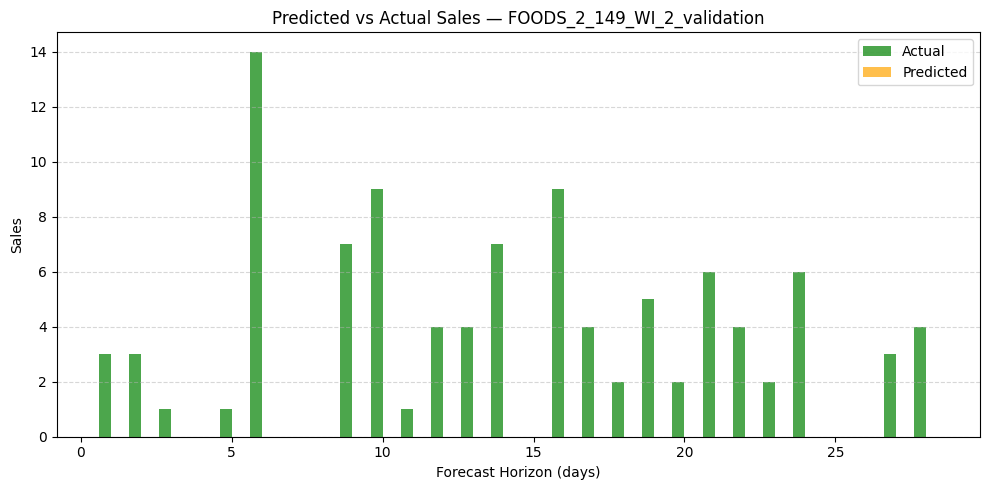

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Choose one item by ID (you can change this)
item_id = "FOODS_2_149_WI_2_validation"   # example from your plot

# Extract actual and predicted rows for that item
row = df_eval[df_eval['id'] == item_id].iloc[0]

actual = row[[c for c in df_eval.columns if c.startswith('d_')]].values
pred   = row[[c for c in df_eval.columns if c.startswith('F')]].values

# X-axis positions
days = np.arange(1, 29)

# Plot
plt.figure(figsize=(10,5))
plt.bar(days - 0.2, actual, width=0.4, label='Actual', color='green', alpha=0.7)
plt.bar(days + 0.2, pred,   width=0.4, label='Predicted', color='orange', alpha=0.7)

plt.title(f'Predicted vs Actual Sales — {item_id}')
plt.xlabel('Forecast Horizon (days)')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Option 2: Compare a few random items together

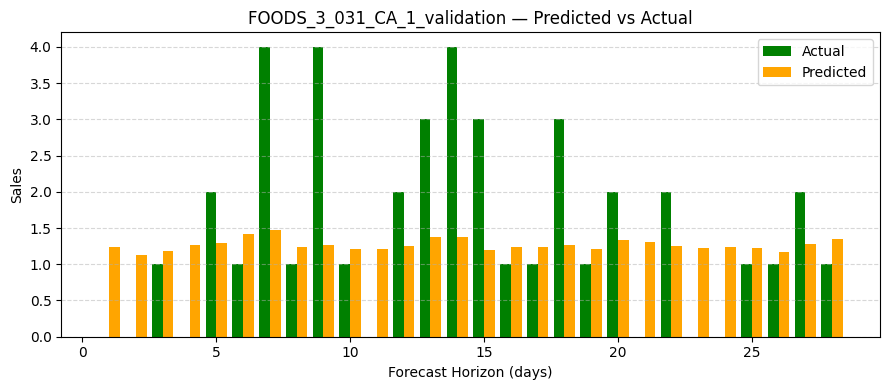

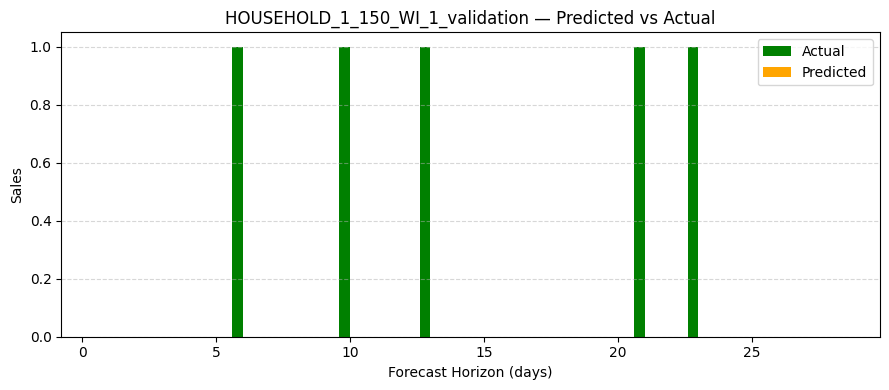

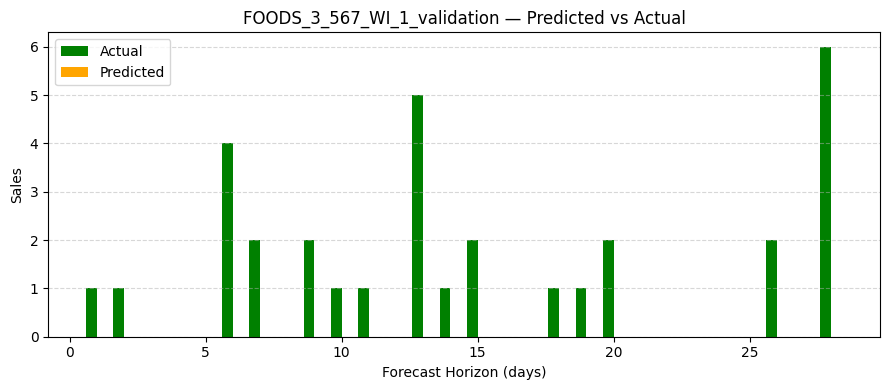

In [37]:
sample_items = np.random.choice(df_eval['id'], 3, replace=False)

for item_id in sample_items:
    row = df_eval[df_eval['id'] == item_id].iloc[0]
    actual = row[[c for c in df_eval.columns if c.startswith('d_')]].values
    pred   = row[[c for c in df_eval.columns if c.startswith('F')]].values

    plt.figure(figsize=(9,4))
    plt.bar(np.arange(1,29)-0.2, actual, width=0.4, label='Actual', color='green')
    plt.bar(np.arange(1,29)+0.2, pred,   width=0.4, label='Predicted', color='orange')
    plt.title(f'{item_id} — Predicted vs Actual')
    plt.xlabel('Forecast Horizon (days)')
    plt.ylabel('Sales')
    plt.legend()
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


Option 3: Aggregate view — average actual vs predicted

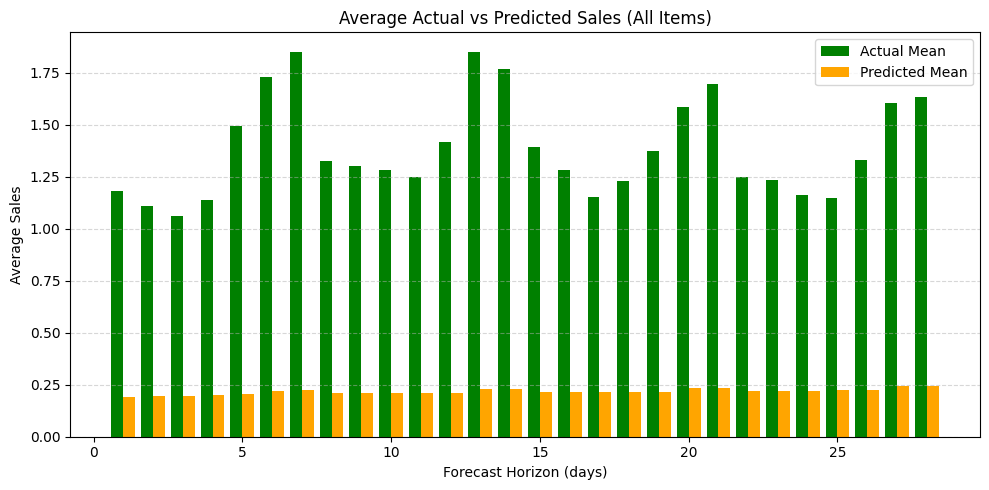

In [38]:
# Compute mean across all items for each day
mean_actual = y_true_np.mean(axis=0)
mean_pred   = y_pred_np.mean(axis=0)

days = np.arange(1, 29)

plt.figure(figsize=(10,5))
plt.bar(days - 0.2, mean_actual, width=0.4, label='Actual Mean', color='green')
plt.bar(days + 0.2, mean_pred,   width=0.4, label='Predicted Mean', color='orange')
plt.title('Average Actual vs Predicted Sales (All Items)')
plt.xlabel('Forecast Horizon (days)')
plt.ylabel('Average Sales')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Option 4: Compare per-category or per-store averages

      cat_id  actual_mean  pred_mean
0      FOODS     1.965732   0.258857
1    HOBBIES     0.700215   0.184840
2  HOUSEHOLD     0.961659   0.175774


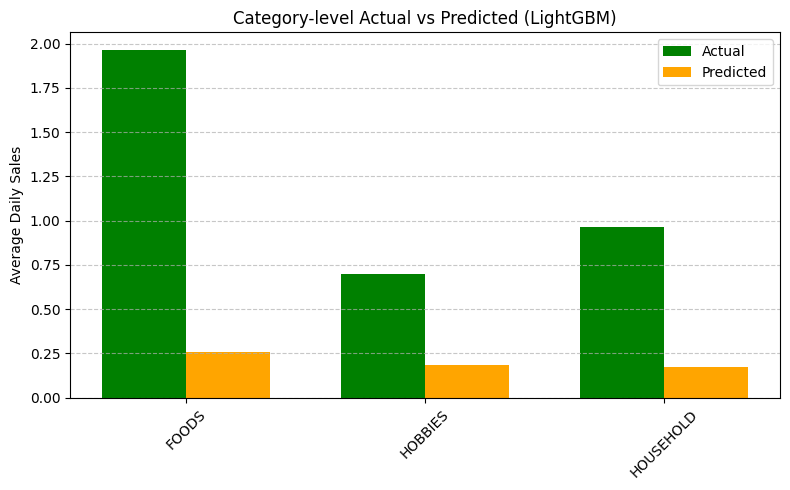

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------
# 1) Rebuild clean numeric arrays from your eval df
#    (this is the df you used to compute RMSE/MAE/MAPE)
# ---------------------------------------------------
# Example: df_eval contains id + last-28 true days + F1..F28 predictions
# If your column naming is different, just adjust the filters below.

val_cols = [c for c in df_eval.columns if c.startswith('d_')]   # true days
pred_cols = [c for c in df_eval.columns if c.startswith('F')]   # predicted F1..F28

y_true_np = df_eval[val_cols].to_numpy(dtype=np.float32)
y_pred_np = df_eval[pred_cols].to_numpy(dtype=np.float32)

# ---------------------------------------------------
# 2) Build a per-id table with mean actual & predicted
# ---------------------------------------------------
per_id = df_eval[['id']].copy()
per_id['actual_mean'] = y_true_np.mean(axis=1)
per_id['pred_mean']   = y_pred_np.mean(axis=1)

# Attach category info from sales_train_validation
meta = pd.read_csv("sales_train_validation.csv")[['id', 'cat_id']]
per_id = per_id.merge(meta, on='id', how='left')

# Aggregate by category
category_stats = (
    per_id
    .groupby('cat_id')[['actual_mean','pred_mean']]
    .mean()
    .reset_index()
)

print(category_stats)

# ---------------------------------------------------
# 3) Side-by-side bar plot
# ---------------------------------------------------
x = np.arange(len(category_stats))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, category_stats['actual_mean'], width,
        label='Actual', color='green')
plt.bar(x + width/2, category_stats['pred_mean'], width,
        label='Predicted', color='orange')

plt.xticks(x, category_stats['cat_id'], rotation=45)
plt.ylabel('Average Daily Sales')
plt.title('Category-level Actual vs Predicted (LightGBM)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Stacked Bar Chart: Actual vs Predicted per Category

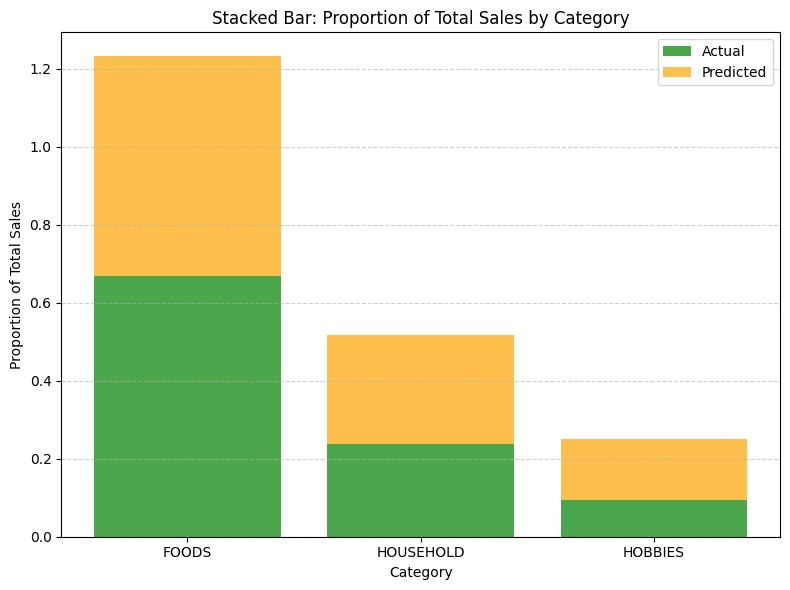

In [40]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load category info
meta = pd.read_csv("sales_train_validation.csv")[['id', 'cat_id', 'store_id']]

# Merge with your evaluation dataset
df_bar = df_eval[['id']].copy()
df_bar['Actual_Total'] = y_true_np.sum(axis=1)
df_bar['Pred_Total'] = y_pred_np.sum(axis=1)
df_bar = df_bar.merge(meta, on='id', how='left')

# Aggregate totals per category
cat_summary = (
    df_bar.groupby('cat_id')[['Actual_Total', 'Pred_Total']]
    .sum()
    .reset_index()
)

# Compute proportions
cat_summary['Actual_Prop'] = cat_summary['Actual_Total'] / cat_summary['Actual_Total'].sum()
cat_summary['Pred_Prop'] = cat_summary['Pred_Total'] / cat_summary['Pred_Total'].sum()

# Sort by actual proportion
cat_summary = cat_summary.sort_values('Actual_Prop', ascending=False)

# --- Plot stacked bars ---
plt.figure(figsize=(8,6))
plt.bar(cat_summary['cat_id'], cat_summary['Actual_Prop'],
        label='Actual', color='green', alpha=0.7)
plt.bar(cat_summary['cat_id'], cat_summary['Pred_Prop'],
        bottom=cat_summary['Actual_Prop'], label='Predicted', color='orange', alpha=0.7)

plt.title('Stacked Bar: Proportion of Total Sales by Category')
plt.ylabel('Proportion of Total Sales')
plt.xlabel('Category')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


🧠 Interpretation:

Color	Meaning	Insight

🟩 Green bar	Actual sales proportion	True share of each category

🟧 Orange bar	Model-predicted share	If it extends beyond green → over-prediction; if shorter → under-prediction

For example:

If FOODS_3 has a taller orange segment → model overestimates it.

If HOBBIES_2 has barely any orange → model underpredicts.

Side-by-Side Bar Chart: Actual vs Predicted by Category

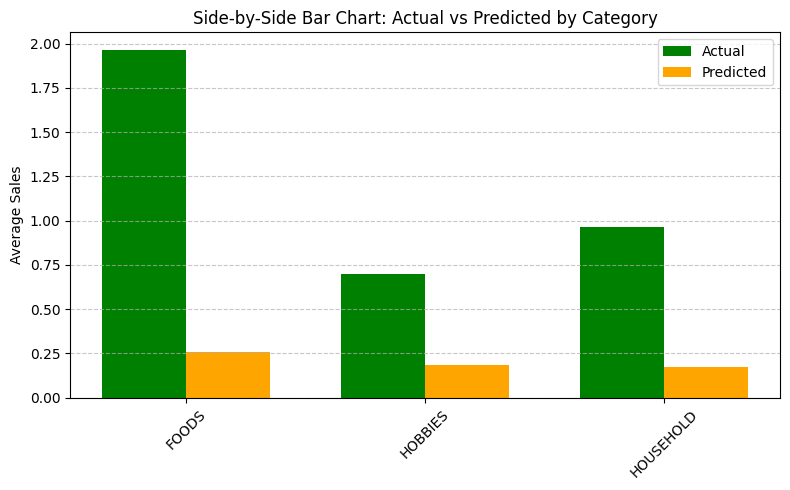

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Merge category info
meta = pd.read_csv("sales_train_validation.csv")[['id','cat_id']]
df_bar = df_eval[['id']].copy()
df_bar['Actual'] = y_true_np.mean(axis=1)
df_bar['Predicted'] = y_pred_np.mean(axis=1)
df_bar = df_bar.merge(meta, on='id', how='left')

# Aggregate by category
cat_stats = df_bar.groupby('cat_id')[['Actual','Predicted']].mean().reset_index()

# Plot
x = np.arange(len(cat_stats))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, cat_stats['Actual'], width, color='green', label='Actual')
plt.bar(x + width/2, cat_stats['Predicted'], width, color='orange', label='Predicted')
plt.xticks(x, cat_stats['cat_id'], rotation=45)
plt.ylabel('Average Sales')
plt.title('Side-by-Side Bar Chart: Actual vs Predicted by Category')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
